In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib as plt

In [2]:
df_pib = pd.read_csv("../dados/processed/pib_tratado.csv")

print(f"Total de linhas: {df_pib.shape[0]}")
print(f"Total de colunas: {df_pib.shape[1]}")
print(f"Valores preenchidos (não nulos) em 'valor': {df_pib['valor'].notna().sum()}")
print(f"Valores nulos em 'valor': {df_pib['valor'].isna().sum()}")

df_pib.head()

Total de linhas: 15624
Total de colunas: 11
Valores preenchidos (não nulos) em 'valor': 14508
Valores nulos em 'valor': 1116


,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,valor,valor_is_inibido
0,N1,Brasil,1,Brasil,2003,2003,37,Produto Interno Bruto a preços correntes,Mil Reais,1.717950e+09,0
1,N1,Brasil,1,Brasil,2004,2004,37,Produto Interno Bruto a preços correntes,Mil Reais,1.957751e+09,0
2,N1,Brasil,1,Brasil,2005,2005,37,Produto Interno Bruto a preços correntes,Mil Reais,2.170585e+09,0
3,N1,Brasil,1,Brasil,2006,2006,37,Produto Interno Bruto a preços correntes,Mil Reais,2.409450e+09,0
4,N1,Brasil,1,Brasil,2007,2007,37,Produto Interno Bruto a preços correntes,Mil Reais,2.720263e+09,0


In [3]:
cols_codigo = [c for c in df_pib.columns if c.endswith("_codigo")]
df_pib_sem_codigo = df_pib.drop(columns=cols_codigo)

df_pib_sem_codigo.head()

,nivel_territorial_nome,territorio_nome,ano_nome,variavel_nome,unidade,valor,valor_is_inibido
0,Brasil,Brasil,2003,Produto Interno Bruto a preços correntes,Mil Reais,1.717950e+09,0
1,Brasil,Brasil,2004,Produto Interno Bruto a preços correntes,Mil Reais,1.957751e+09,0
2,Brasil,Brasil,2005,Produto Interno Bruto a preços correntes,Mil Reais,2.170585e+09,0
3,Brasil,Brasil,2006,Produto Interno Bruto a preços correntes,Mil Reais,2.409450e+09,0
4,Brasil,Brasil,2007,Produto Interno Bruto a preços correntes,Mil Reais,2.720263e+09,0


In [4]:
print(f"Territórios únicos: {df_pib_sem_codigo['territorio_nome'].nunique()}")

df_pib_sem_codigo['territorio_nome'].value_counts()

Territórios únicos: 186


territorio_nome
Brasil                  84
Ceará                   84
Abaiara - CE            84
Acarape - CE            84
Acaraú - CE             84
                        ..
Uruburetama - CE        84
Uruoca - CE             84
Varjota - CE            84
Várzea Alegre - CE      84
Viçosa do Ceará - CE    84
Name: count, Length: 186, dtype: int64

In [5]:
print(f"Menor ano: {df_pib_sem_codigo['ano_nome'].min()}")
print(f"Maior ano: {df_pib_sem_codigo['ano_nome'].max()}")

Menor ano: 2003
Maior ano: 2023


In [6]:
anos_disponiveis = sorted(int(a) for a in df_pib_sem_codigo['ano_nome'].unique())
print(f"Total de anos: {len(anos_disponiveis)}")
print(anos_disponiveis)

Total de anos: 21
[2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


## PIB — Brasil x Ceará

Como o PIB do Brasil e do Ceará evoluíram entre 2003 e 2023?

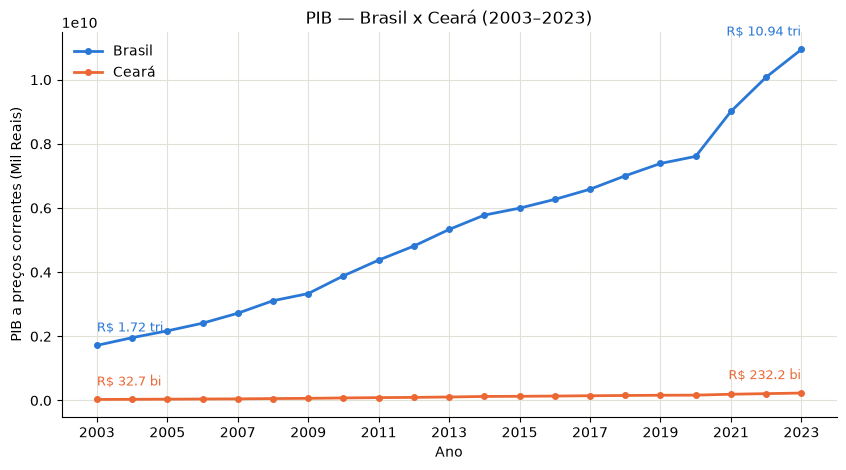

In [7]:
import matplotlib.pyplot as plt

pib_bc = df_pib_sem_codigo[
    (df_pib_sem_codigo["territorio_nome"].isin(["Brasil", "Ceará"]))
    & (df_pib_sem_codigo["variavel_nome"] == "Produto Interno Bruto a preços correntes")
].copy()
pib_bc["ano_nome"] = pib_bc["ano_nome"].astype(int)
pib_bc = pib_bc.sort_values("ano_nome")

cores = {"Brasil": "#2a78d6", "Ceará": "#eb6834"}


def formata_reais(valor_mil_reais):
    reais = valor_mil_reais * 1_000
    if reais >= 1e12:
        return f"R$ {reais / 1e12:.2f} tri"
    return f"R$ {reais / 1e9:.1f} bi"


fig, ax = plt.subplots(figsize=(10, 5))
for territorio, cor in cores.items():
    serie = pib_bc[pib_bc["territorio_nome"] == territorio]
    ax.plot(serie["ano_nome"], serie["valor"], color=cor, linewidth=2, marker="o", markersize=4, label=territorio)

    primeiro = serie.iloc[0]
    ultimo = serie.iloc[-1]
    ax.annotate(
        formata_reais(primeiro["valor"]),
        (primeiro["ano_nome"], primeiro["valor"]),
        textcoords="offset points", xytext=(0, 10), ha="left", fontsize=9, color=cor,
    )
    ax.annotate(
        formata_reais(ultimo["valor"]),
        (ultimo["ano_nome"], ultimo["valor"]),
        textcoords="offset points", xytext=(0, 10), ha="right", fontsize=9, color=cor,
    )

ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais)")
ax.set_title("PIB — Brasil x Ceará (2003–2023)")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

In [8]:
pib_pivot = pib_bc.pivot(index="ano_nome", columns="territorio_nome", values="valor")

In [9]:
razao_valor = pib_pivot["Brasil"] / pib_pivot["Ceará"]

for ano, razao in razao_valor.items():
    print(f"{ano}: PIB do Brasil é {razao:.2f}x o PIB do Ceará")

2003: PIB do Brasil é 52.56x o PIB do Ceará
2004: PIB do Brasil é 53.07x o PIB do Ceará
2005: PIB do Brasil é 52.86x o PIB do Ceará
2006: PIB do Brasil é 51.82x o PIB do Ceará
2007: PIB do Brasil é 53.53x o PIB do Ceará
2008: PIB do Brasil é 51.47x o PIB do Ceará
2009: PIB do Brasil é 49.60x o PIB do Ceará
2010: PIB do Brasil é 48.98x o PIB do Ceará
2011: PIB do Brasil é 48.79x o PIB do Ceará
2012: PIB do Brasil é 49.65x o PIB do Ceará
2013: PIB do Brasil é 48.90x o PIB do Ceará
2014: PIB do Brasil é 45.84x o PIB do Ceará
2015: PIB do Brasil é 45.90x o PIB do Ceará
2016: PIB do Brasil é 45.29x o PIB do Ceará
2017: PIB do Brasil é 44.52x o PIB do Ceará
2018: PIB do Brasil é 44.93x o PIB do Ceará
2019: PIB do Brasil é 45.17x o PIB do Ceará
2020: PIB do Brasil é 45.59x o PIB do Ceará
2021: PIB do Brasil é 46.24x o PIB do Ceará
2022: PIB do Brasil é 47.19x o PIB do Ceará
2023: PIB do Brasil é 47.12x o PIB do Ceará


In [10]:
crescimento = {}
for territorio in ["Brasil", "Ceará"]:
    serie = pib_bc[pib_bc["territorio_nome"] == territorio]
    valor_2003 = serie[serie["ano_nome"] == 2003]["valor"].iloc[0]
    valor_2023 = serie[serie["ano_nome"] == 2023]["valor"].iloc[0]
    crescimento[territorio] = valor_2023 / valor_2003

print(f"Brasil cresceu {crescimento['Brasil']:.2f}x (2003 -> 2023)")
print(f"Ceará cresceu {crescimento['Ceará']:.2f}x (2003 -> 2023)")
print(f"Brasil cresceu {crescimento['Brasil'] / crescimento['Ceará']:.2f}x mais que o Ceará")

Brasil cresceu 6.37x (2003 -> 2023)
Ceará cresceu 7.10x (2003 -> 2023)
Brasil cresceu 0.90x mais que o Ceará


In [11]:
valores = {}
for territorio in ["Brasil", "Ceará"]:
    serie = pib_bc[pib_bc["territorio_nome"] == territorio]
    valores[territorio] = {
        2003: serie[serie["ano_nome"] == 2003]["valor"].iloc[0],
        2023: serie[serie["ano_nome"] == 2023]["valor"].iloc[0],
    }

dif_2003 = valores["Brasil"][2003] - valores["Ceará"][2003]
dif_2023 = valores["Brasil"][2023] - valores["Ceará"][2023]
vezes_2003 = valores["Brasil"][2003] / valores["Ceará"][2003]
vezes_2023 = valores["Brasil"][2023] / valores["Ceará"][2023]

print(f"2003 — Brasil: {formata_reais(valores['Brasil'][2003])} | Ceará: {formata_reais(valores['Ceará'][2003])}")
print(f"Diferença 2003: {formata_reais(dif_2003)} ({vezes_2003:.2f}x)")
print()
print(f"2023 — Brasil: {formata_reais(valores['Brasil'][2023])} | Ceará: {formata_reais(valores['Ceará'][2023])}")
print(f"Diferença 2023: {formata_reais(dif_2023)} ({vezes_2023:.2f}x)")

2003 — Brasil: R$ 1.72 tri | Ceará: R$ 32.7 bi
Diferença 2003: R$ 1.69 tri (52.56x)

2023 — Brasil: R$ 10.94 tri | Ceará: R$ 232.2 bi
Diferença 2023: R$ 10.71 tri (47.12x)


Quantas vezes o PIB de cada um cresceu, ano a ano, em relação a 2003?

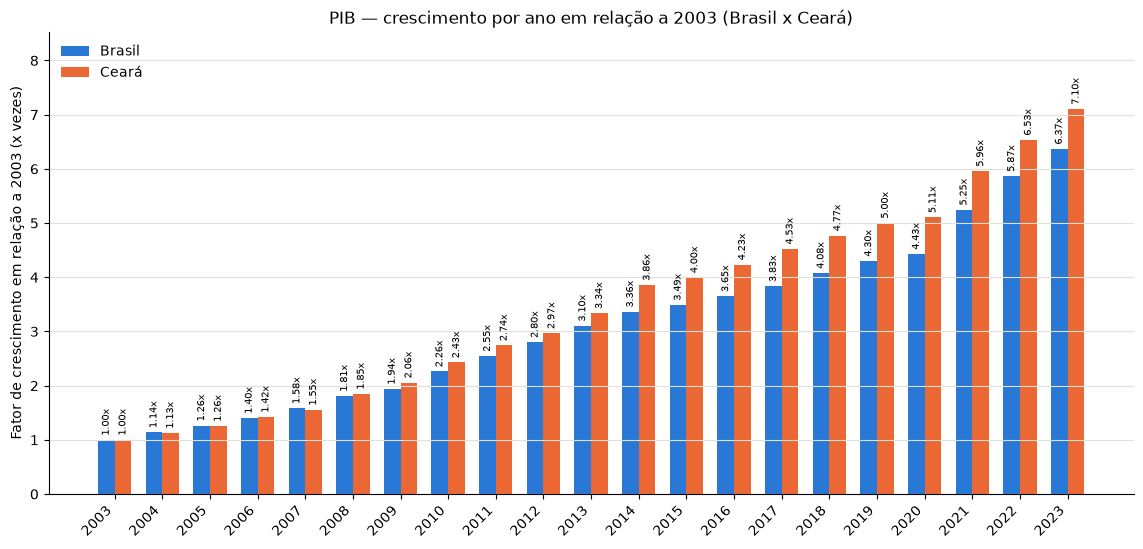

In [12]:
import numpy as np

cresc_por_ano = pib_pivot[["Brasil", "Ceará"]].div(pib_pivot.loc[2003, ["Brasil", "Ceará"]])
anos = cresc_por_ano.index.to_numpy()
x = np.arange(len(anos))
largura = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
barras_brasil = ax.bar(x - largura / 2, cresc_por_ano["Brasil"], width=largura, color=cores["Brasil"], label="Brasil")
barras_ceara = ax.bar(x + largura / 2, cresc_por_ano["Ceará"], width=largura, color=cores["Ceará"], label="Ceará")

for barras in (barras_brasil, barras_ceara):
    ax.bar_label(barras, fmt="%.2fx", fontsize=7, rotation=90, padding=3)

ax.set_xticks(x)
ax.set_xticklabels(anos, rotation=45, ha="right")
ax.set_ylabel("Fator de crescimento em relação a 2003 (x vezes)")
ax.set_title("PIB — crescimento por ano em relação a 2003 (Brasil x Ceará)")
ax.set_ylim(0, cresc_por_ano.to_numpy().max() * 1.2)
ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

In [13]:
razao_crescimento = cresc_por_ano["Brasil"] / cresc_por_ano["Ceará"]

for ano in cresc_por_ano.index:
    cresc_brasil = cresc_por_ano.loc[ano, "Brasil"]
    cresc_ceara = cresc_por_ano.loc[ano, "Ceará"]
    razao = razao_crescimento.loc[ano]
    print(f"{ano}: Brasil cresceu {cresc_brasil:.2f}x, Ceará cresceu {cresc_ceara:.2f}x, então o Brasil cresceu {razao:.2f}x em relação ao Ceará")

2003: Brasil cresceu 1.00x, Ceará cresceu 1.00x, então o Brasil cresceu 1.00x em relação ao Ceará
2004: Brasil cresceu 1.14x, Ceará cresceu 1.13x, então o Brasil cresceu 1.01x em relação ao Ceará
2005: Brasil cresceu 1.26x, Ceará cresceu 1.26x, então o Brasil cresceu 1.01x em relação ao Ceará
2006: Brasil cresceu 1.40x, Ceará cresceu 1.42x, então o Brasil cresceu 0.99x em relação ao Ceará
2007: Brasil cresceu 1.58x, Ceará cresceu 1.55x, então o Brasil cresceu 1.02x em relação ao Ceará
2008: Brasil cresceu 1.81x, Ceará cresceu 1.85x, então o Brasil cresceu 0.98x em relação ao Ceará
2009: Brasil cresceu 1.94x, Ceará cresceu 2.06x, então o Brasil cresceu 0.94x em relação ao Ceará
2010: Brasil cresceu 2.26x, Ceará cresceu 2.43x, então o Brasil cresceu 0.93x em relação ao Ceará
2011: Brasil cresceu 2.55x, Ceará cresceu 2.74x, então o Brasil cresceu 0.93x em relação ao Ceará
2012: Brasil cresceu 2.80x, Ceará cresceu 2.97x, então o Brasil cresceu 0.94x em relação ao Ceará
2013: Brasil cresceu

Quantas vezes o PIB do Brasil é maior que o do Ceará, em cada ano?

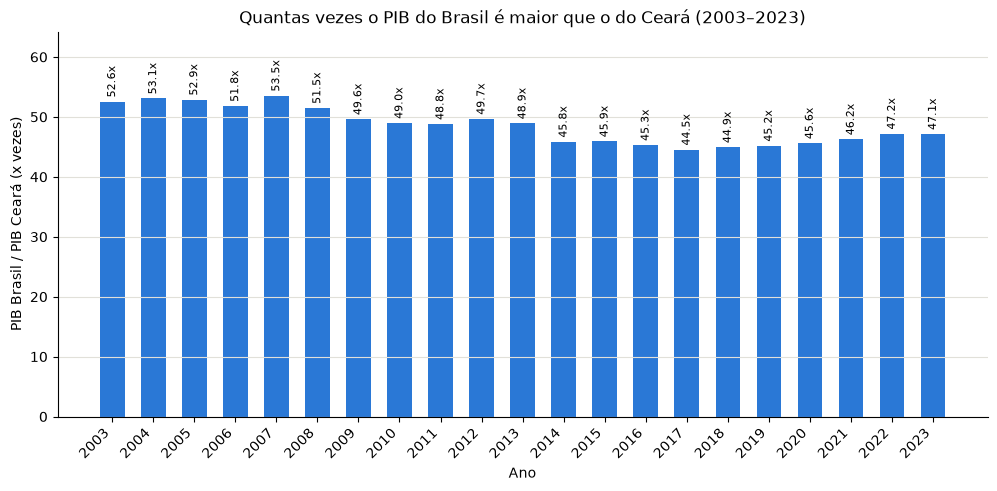

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.bar(razao_valor.index, razao_valor.values, color="#2a78d6", width=0.6)
ax.bar_label(barras, fmt="%.1fx", fontsize=8, rotation=90, padding=3)

ax.set_xlabel("Ano")
ax.set_ylabel("PIB Brasil / PIB Ceará (x vezes)")
ax.set_title("Quantas vezes o PIB do Brasil é maior que o do Ceará (2003–2023)")
ax.set_xticks(razao_valor.index)
ax.set_xticklabels(razao_valor.index, rotation=45, ha="right")
ax.set_ylim(0, razao_valor.max() * 1.2)
ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

In [15]:
ano_maior = razao_valor.idxmax()
ano_menor = razao_valor.idxmin()

print(f"Maior razão: {ano_maior} — Brasil {razao_valor.loc[ano_maior]:.2f}x o Ceará")
print(f"Menor razão: {ano_menor} — Brasil {razao_valor.loc[ano_menor]:.2f}x o Ceará")

Maior razão: 2007 — Brasil 53.53x o Ceará
Menor razão: 2017 — Brasil 44.52x o Ceará


In [16]:
participacao_ceara = (pib_pivot["Ceará"] / pib_pivot["Brasil"]) * 100

for ano, pct in participacao_ceara.items():
    print(f"{ano}: Ceará representa {pct:.2f}% do PIB do Brasil")

2003: Ceará representa 1.90% do PIB do Brasil
2004: Ceará representa 1.88% do PIB do Brasil
2005: Ceará representa 1.89% do PIB do Brasil
2006: Ceará representa 1.93% do PIB do Brasil
2007: Ceará representa 1.87% do PIB do Brasil
2008: Ceará representa 1.94% do PIB do Brasil
2009: Ceará representa 2.02% do PIB do Brasil
2010: Ceará representa 2.04% do PIB do Brasil
2011: Ceará representa 2.05% do PIB do Brasil
2012: Ceará representa 2.01% do PIB do Brasil
2013: Ceará representa 2.05% do PIB do Brasil
2014: Ceará representa 2.18% do PIB do Brasil
2015: Ceará representa 2.18% do PIB do Brasil
2016: Ceará representa 2.21% do PIB do Brasil
2017: Ceará representa 2.25% do PIB do Brasil
2018: Ceará representa 2.23% do PIB do Brasil
2019: Ceará representa 2.21% do PIB do Brasil
2020: Ceará representa 2.19% do PIB do Brasil
2021: Ceará representa 2.16% do PIB do Brasil
2022: Ceará representa 2.12% do PIB do Brasil
2023: Ceará representa 2.12% do PIB do Brasil


Qual a participação do Ceará no PIB do Brasil, ano a ano?

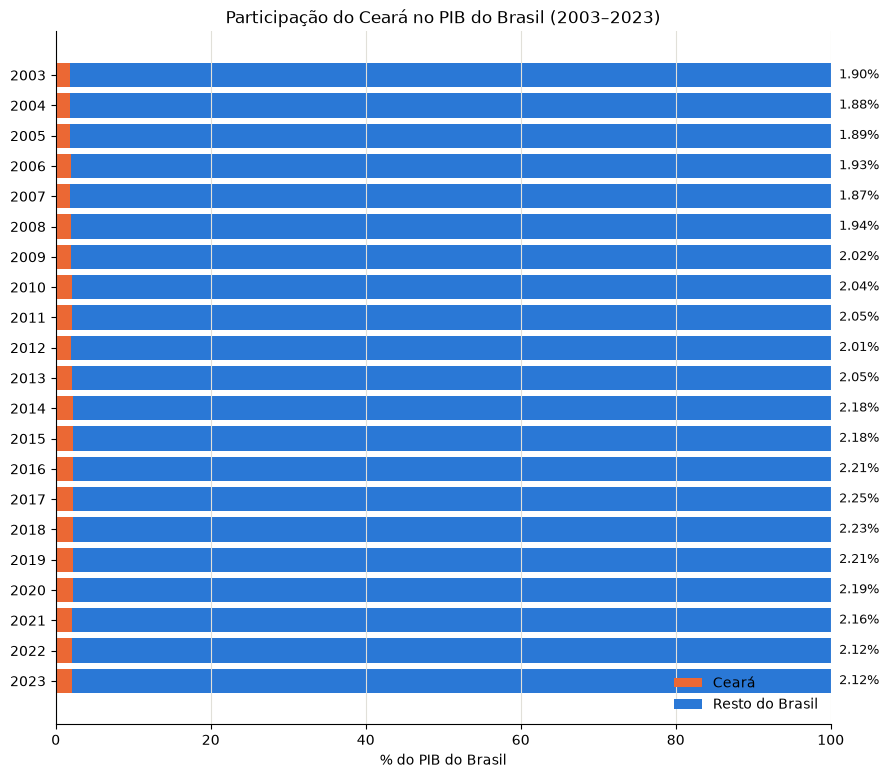

In [17]:
anos_pct = participacao_ceara.index
resto_brasil = 100 - participacao_ceara

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(anos_pct, participacao_ceara, color=cores["Ceará"], label="Ceará")
ax.barh(anos_pct, resto_brasil, left=participacao_ceara, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in participacao_ceara.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(anos_pct)
ax.invert_yaxis()
ax.set_xlabel("% do PIB do Brasil")
ax.set_title("Participação do Ceará no PIB do Brasil (2003–2023)")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

Como essa participação do Ceará mudou entre 2003 e 2023?

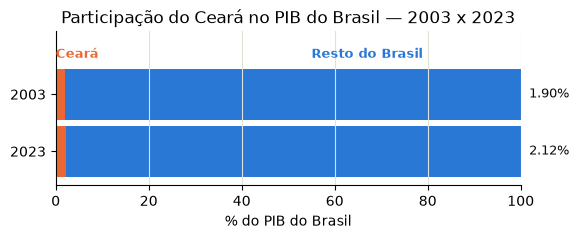

In [18]:
anos_resumo = [2003, 2023]
participacao_resumo = participacao_ceara.loc[anos_resumo]
resto_resumo = 100 - participacao_resumo
y_pos = [0, 1]

fig, ax = plt.subplots(figsize=(6, 2))
ax.barh(y_pos, participacao_resumo, height=0.9, color=cores["Ceará"])
ax.barh(y_pos, resto_resumo, left=participacao_resumo, height=0.9, color=cores["Brasil"])

for y, pct in zip(y_pos, participacao_resumo):
    ax.annotate(
        f"{pct:.2f}%",
        (100, y),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.annotate(
    "Ceará", (0, -0.7), xytext=(0, -0.7), ha="left", va="center", fontsize=9, color=cores["Ceará"], fontweight="bold",
)
ax.annotate(
    "Resto do Brasil", (55, -0.7), xytext=(55, -0.7), ha="left", va="center", fontsize=9, color=cores["Brasil"], fontweight="bold",
)

ax.set_yticks(y_pos)
ax.set_yticklabels(anos_resumo)
ax.invert_yaxis()
ax.set_ylim(1.6, -1.1)
ax.set_xlabel("% do PIB do Brasil")
ax.set_title("Participação do Ceará no PIB do Brasil — 2003 x 2023")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

## PIB — Municípios do Ceará

In [19]:
df_municipios = df_pib_sem_codigo[df_pib_sem_codigo["nivel_territorial_nome"] == "Município"].copy()

print(f"Total de linhas: {df_municipios.shape[0]}")
print(f"Municípios únicos: {df_municipios['territorio_nome'].nunique()}")

df_municipios.head()

Total de linhas: 15456
Municípios únicos: 184


,nivel_territorial_nome,territorio_nome,ano_nome,variavel_nome,unidade,valor,valor_is_inibido
42,Município,Abaiara - CE,2003,Produto Interno Bruto a preços correntes,Mil Reais,17657.0,0
43,Município,Abaiara - CE,2004,Produto Interno Bruto a preços correntes,Mil Reais,16808.0,0
44,Município,Abaiara - CE,2005,Produto Interno Bruto a preços correntes,Mil Reais,17153.0,0
45,Município,Abaiara - CE,2006,Produto Interno Bruto a preços correntes,Mil Reais,22869.0,0
46,Município,Abaiara - CE,2007,Produto Interno Bruto a preços correntes,Mil Reais,25383.0,0


In [20]:
qtd_2003 = (df_municipios["ano_nome"] == 2003).sum()
qtd_2023 = (df_municipios["ano_nome"] == 2023).sum()

print(f"Registros em 2003: {qtd_2003}")
print(f"Registros em 2023: {qtd_2023}")
print(f"Maior valor: {df_municipios['valor'].max()}")
print(f"Menor valor: {df_municipios['valor'].min()}")

Registros em 2003: 736
Registros em 2023: 736
Maior valor: 86939832.0
Menor valor: 0.07


In [21]:
df_municipios["unidade"].value_counts()

unidade
Mil Reais    11592
%             3864
Name: count, dtype: int64

In [22]:
df_municipios_pct = df_municipios[df_municipios["unidade"] == "%"].copy()

print(f"Total de linhas: {df_municipios_pct.shape[0]}")
df_municipios_pct.head(10)

Total de linhas: 3864


,nivel_territorial_nome,territorio_nome,ano_nome,variavel_nome,unidade,valor,valor_is_inibido
11760,Município,Abaiara - CE,2003,Participação do valor adicionado bruto a preço...,%,34.46,0
11761,Município,Abaiara - CE,2004,Participação do valor adicionado bruto a preço...,%,26.28,0
11762,Município,Abaiara - CE,2005,Participação do valor adicionado bruto a preço...,%,18.69,0
11763,Município,Abaiara - CE,2006,Participação do valor adicionado bruto a preço...,%,23.04,0
11764,Município,Abaiara - CE,2007,Participação do valor adicionado bruto a preço...,%,19.74,0
11765,Município,Abaiara - CE,2008,Participação do valor adicionado bruto a preço...,%,21.33,0
11766,Município,Abaiara - CE,2009,Participação do valor adicionado bruto a preço...,%,20.23,0
11767,Município,Abaiara - CE,2010,Participação do valor adicionado bruto a preço...,%,13.07,0
11768,Município,Abaiara - CE,2011,Participação do valor adicionado bruto a preço...,%,18.79,0
11769,Município,Abaiara - CE,2012,Participação do valor adicionado bruto a preço...,%,14.39,0


In [23]:
territorios_pct = set(df_municipios[df_municipios["unidade"] == "%"]["territorio_nome"])
territorios_reais = set(df_municipios[df_municipios["unidade"] == "Mil Reais"]["territorio_nome"])
territorios_ambos = territorios_pct & territorios_reais

print(f"Territórios com %: {len(territorios_pct)}")
print(f"Territórios com Mil Reais: {len(territorios_reais)}")
print(f"Territórios com os dois: {len(territorios_ambos)}")

Territórios com %: 184
Territórios com Mil Reais: 184
Territórios com os dois: 184


In [24]:
df_municipios_reais = df_municipios[df_municipios["unidade"] == "Mil Reais"].copy()

print(f"Total de linhas: {df_municipios_reais.shape[0]}")
df_municipios_reais.head()

Total de linhas: 11592


,nivel_territorial_nome,territorio_nome,ano_nome,variavel_nome,unidade,valor,valor_is_inibido
42,Município,Abaiara - CE,2003,Produto Interno Bruto a preços correntes,Mil Reais,17657.0,0
43,Município,Abaiara - CE,2004,Produto Interno Bruto a preços correntes,Mil Reais,16808.0,0
44,Município,Abaiara - CE,2005,Produto Interno Bruto a preços correntes,Mil Reais,17153.0,0
45,Município,Abaiara - CE,2006,Produto Interno Bruto a preços correntes,Mil Reais,22869.0,0
46,Município,Abaiara - CE,2007,Produto Interno Bruto a preços correntes,Mil Reais,25383.0,0


In [25]:
territorios_municipios = sorted(df_municipios_reais["territorio_nome"].unique())
print(f"Total de territórios: {len(territorios_municipios)}")
print(territorios_municipios)

Total de territórios: 184
['Abaiara - CE', 'Acarape - CE', 'Acaraú - CE', 'Acopiara - CE', 'Aiuaba - CE', 'Alcântaras - CE', 'Altaneira - CE', 'Alto Santo - CE', 'Amontada - CE', 'Antonina do Norte - CE', 'Apuiarés - CE', 'Aquiraz - CE', 'Aracati - CE', 'Aracoiaba - CE', 'Ararendá - CE', 'Araripe - CE', 'Aratuba - CE', 'Arneiroz - CE', 'Assaré - CE', 'Aurora - CE', 'Baixio - CE', 'Banabuiú - CE', 'Barbalha - CE', 'Barreira - CE', 'Barro - CE', 'Barroquinha - CE', 'Baturité - CE', 'Beberibe - CE', 'Bela Cruz - CE', 'Boa Viagem - CE', 'Brejo Santo - CE', 'Camocim - CE', 'Campos Sales - CE', 'Canindé - CE', 'Capistrano - CE', 'Caridade - CE', 'Caririaçu - CE', 'Cariré - CE', 'Cariús - CE', 'Carnaubal - CE', 'Cascavel - CE', 'Catarina - CE', 'Catunda - CE', 'Caucaia - CE', 'Cedro - CE', 'Chaval - CE', 'Chorozinho - CE', 'Choró - CE', 'Coreaú - CE', 'Crateús - CE', 'Crato - CE', 'Croatá - CE', 'Cruz - CE', 'Deputado Irapuan Pinheiro - CE', 'Ereré - CE', 'Eusébio - CE', 'Farias Brito - CE', 

In [26]:
pib_municipios = df_municipios_reais[
    df_municipios_reais["variavel_nome"] == "Produto Interno Bruto a preços correntes"
].copy()
pib_municipios_pivot = pib_municipios.pivot(index="ano_nome", columns="territorio_nome", values="valor")

Qual foi o PIB de Abaiara ao longo do período?

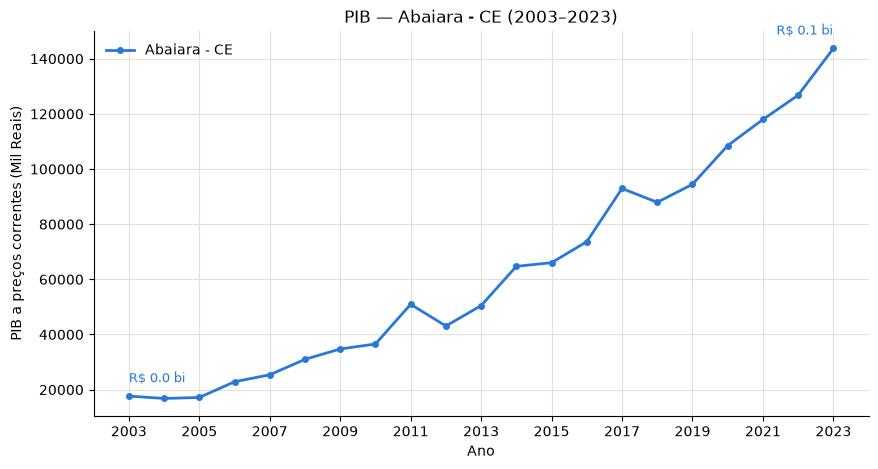

In [27]:
municipio_escolhido = "Abaiara - CE"
serie_municipio = pib_municipios_pivot[municipio_escolhido]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(serie_municipio.index, serie_municipio.values, color="#2a78d6", linewidth=2, marker="o", markersize=4, label=municipio_escolhido)

primeiro_ano, ultimo_ano = serie_municipio.index.min(), serie_municipio.index.max()
ax.annotate(
    formata_reais(serie_municipio.loc[primeiro_ano]),
    (primeiro_ano, serie_municipio.loc[primeiro_ano]),
    textcoords="offset points", xytext=(0, 10), ha="left", fontsize=9, color="#2a78d6",
)
ax.annotate(
    formata_reais(serie_municipio.loc[ultimo_ano]),
    (ultimo_ano, serie_municipio.loc[ultimo_ano]),
    textcoords="offset points", xytext=(0, 10), ha="right", fontsize=9, color="#2a78d6",
)

ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais)")
ax.set_title(f"PIB — {municipio_escolhido} (2003–2023)")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

Como foi o PIB de cada um dos 184 municípios do Ceará?

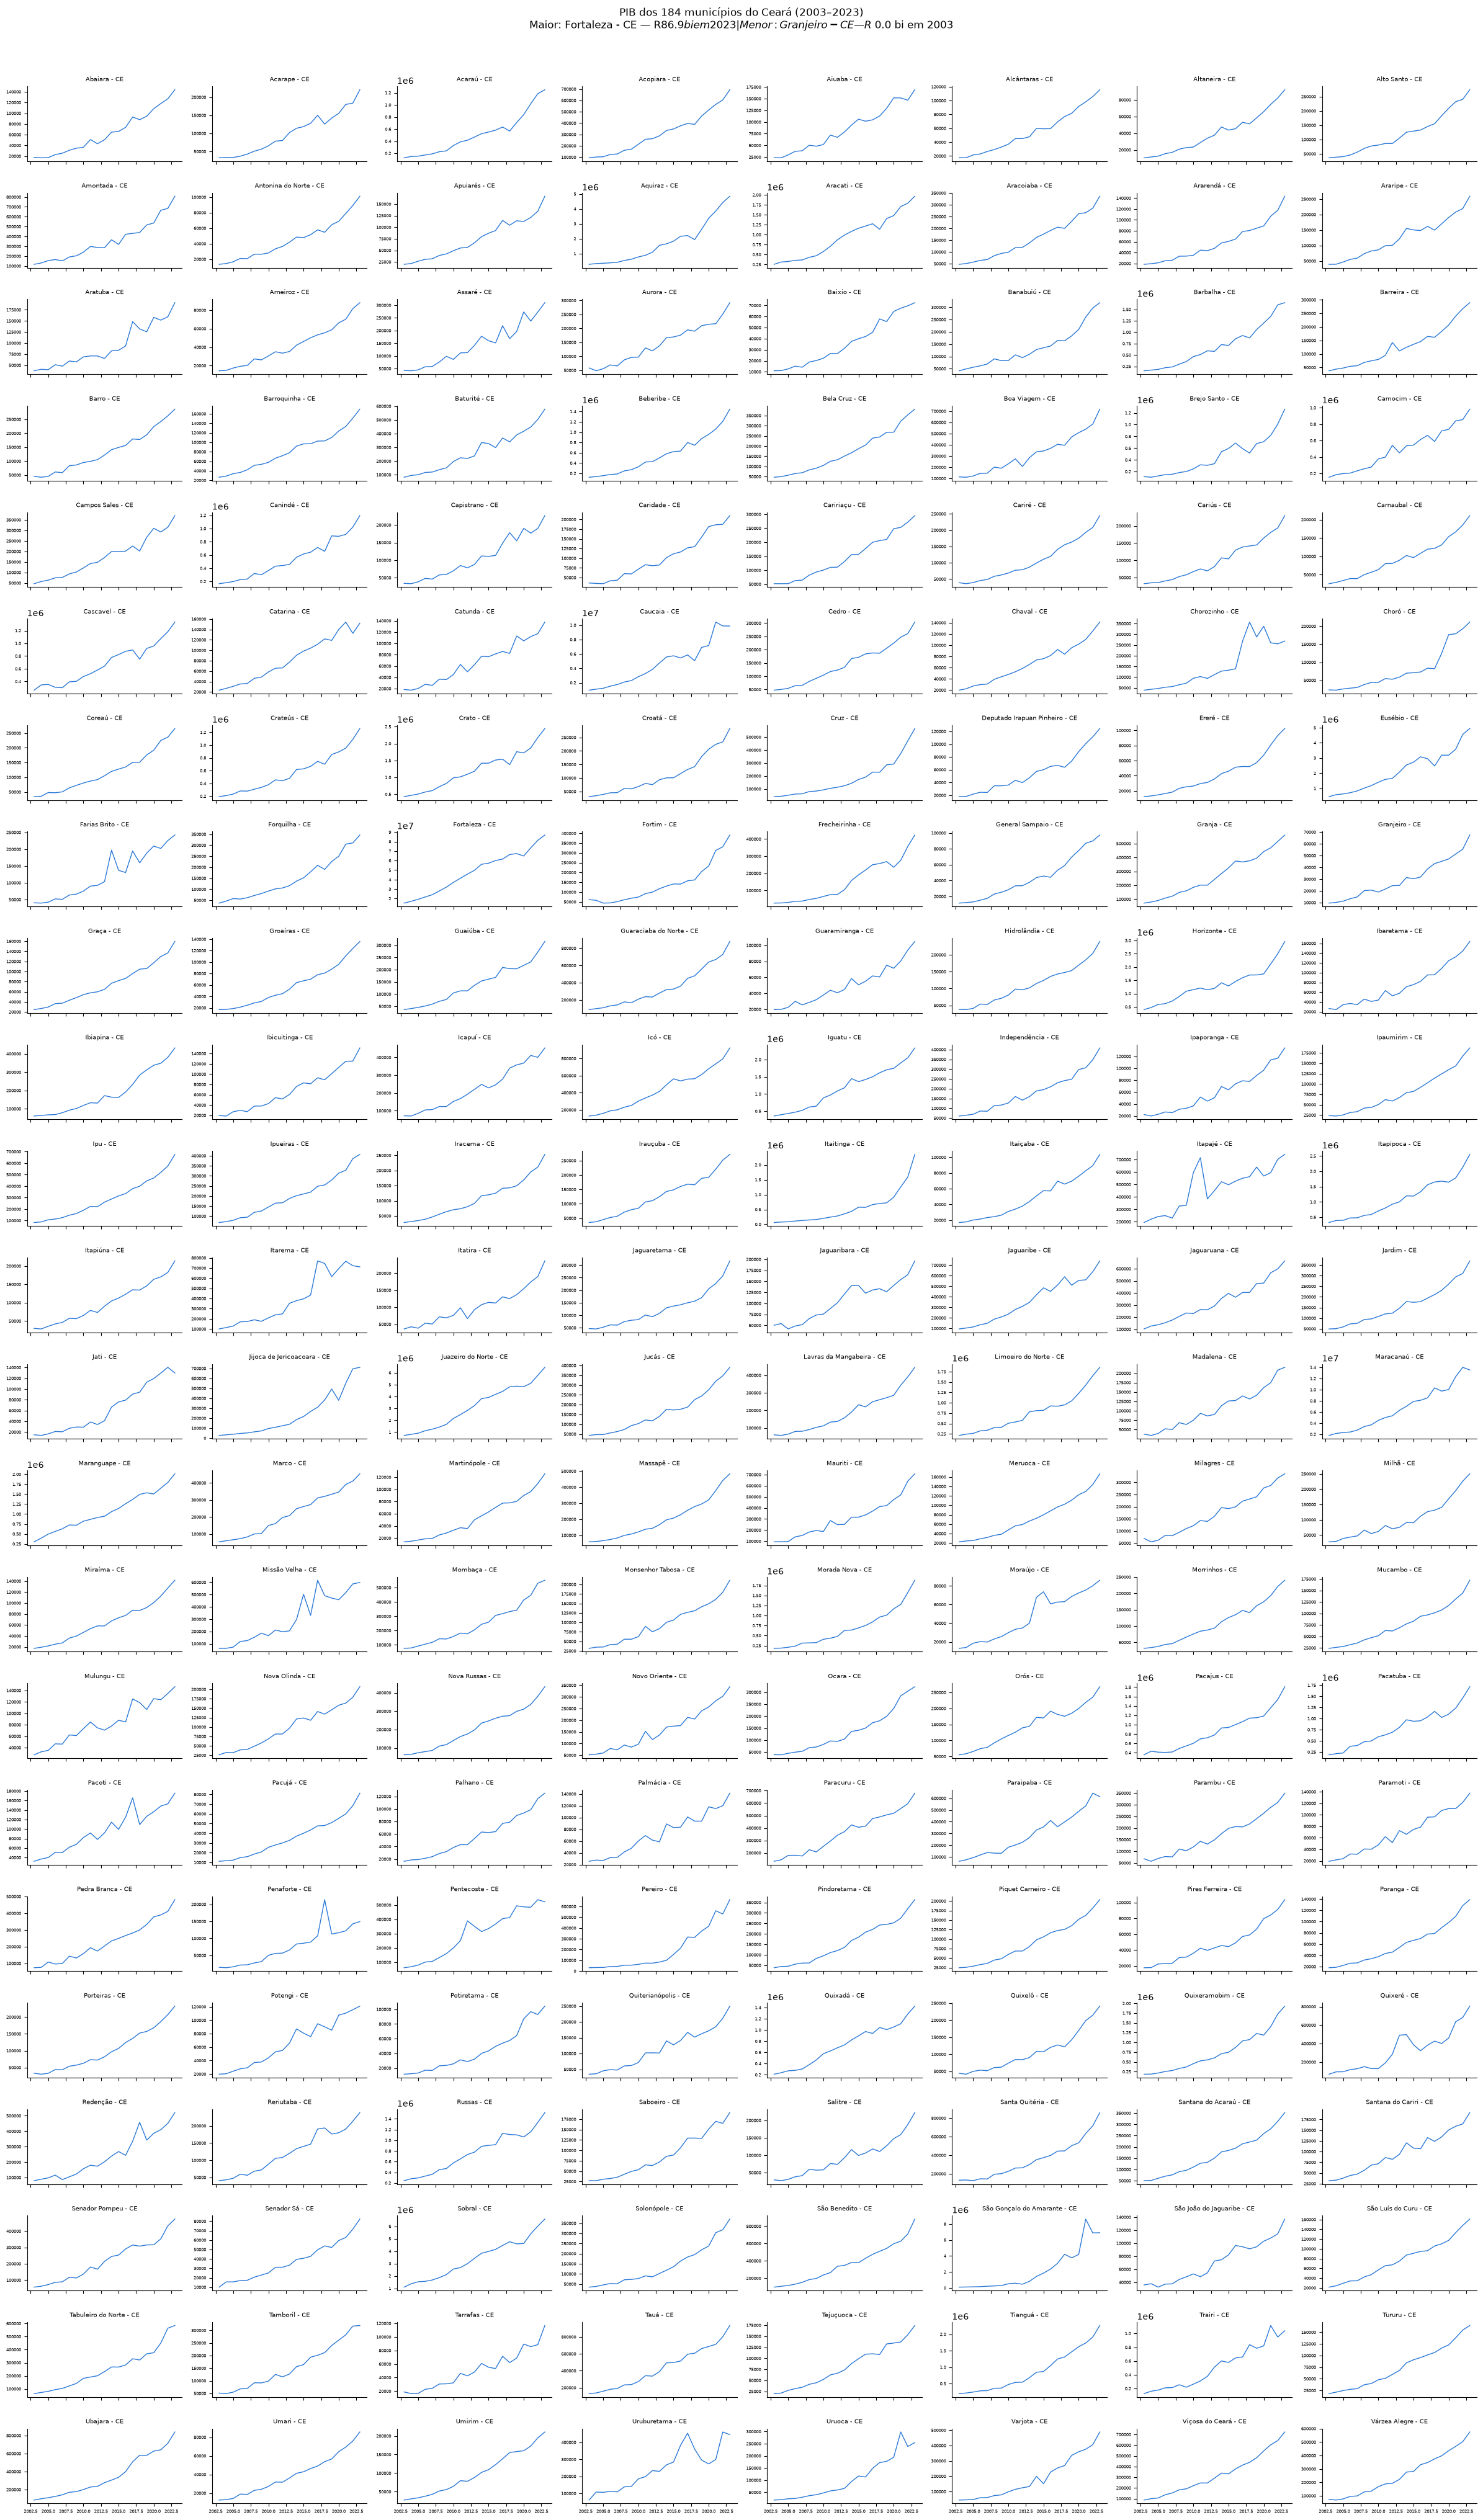

In [28]:
municipios_ordenados = pib_municipios_pivot.columns.tolist()
n_municipios = len(municipios_ordenados)
ncols = 8
nrows = -(-n_municipios // ncols)

valor_max = pib_municipios_pivot.max().max()
municipio_max = pib_municipios_pivot.max().idxmax()
ano_max = pib_municipios_pivot[municipio_max].idxmax()

valor_min = pib_municipios_pivot.min().min()
municipio_min = pib_municipios_pivot.min().idxmin()
ano_min = pib_municipios_pivot[municipio_min].idxmin()

fig, axes = plt.subplots(nrows, ncols, figsize=(24, nrows * 1.8), sharex=True)

for ax, municipio in zip(axes.flat, municipios_ordenados):
    serie = pib_municipios_pivot[municipio]
    ax.plot(serie.index, serie.values, color="#2a78d6", linewidth=1)
    ax.set_title(municipio, fontsize=7)
    ax.tick_params(labelsize=5)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes.flat[n_municipios:]:
    ax.axis("off")

fig.suptitle(
    f"PIB dos {n_municipios} municípios do Ceará (2003–2023)\n"
    f"Maior: {municipio_max} — {formata_reais(valor_max)} em {ano_max} | "
    f"Menor: {municipio_min} — {formata_reais(valor_min)} em {ano_min}",
    fontsize=12,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

Quais os 10 municípios com maior PIB e como eles evoluíram?

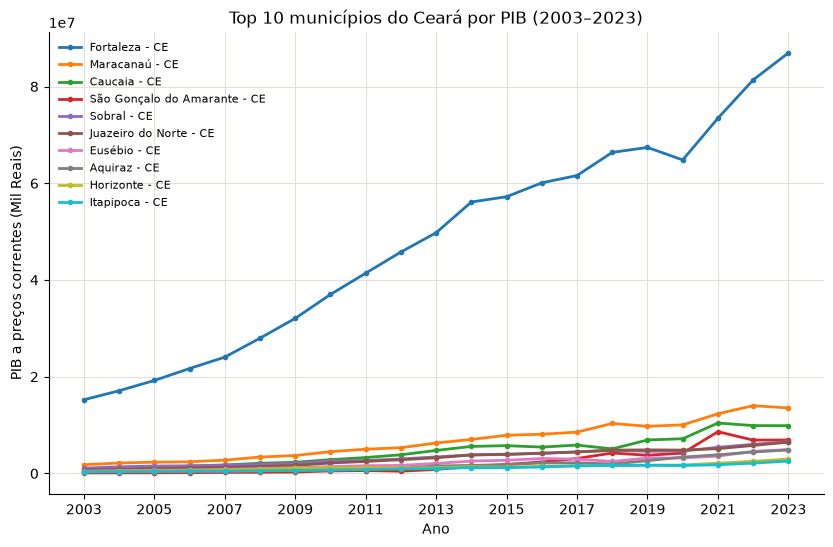

In [29]:
top10_municipios = pib_municipios_pivot.loc[2023].sort_values(ascending=False).head(10).index.tolist()
cores_top10 = plt.colormaps["tab10"].colors

fig, ax = plt.subplots(figsize=(10, 6))
for cor, municipio in zip(cores_top10, top10_municipios):
    serie = pib_municipios_pivot[municipio]
    ax.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais)")
ax.set_title("Top 10 municípios do Ceará por PIB (2003–2023)")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=   0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

### Lista de municípios

In [30]:
for posicao, municipio in enumerate(territorios_municipios, start=1):
    print(f"{posicao:3d}. {municipio}")

  1. Abaiara - CE
  2. Acarape - CE
  3. Acaraú - CE
  4. Acopiara - CE
  5. Aiuaba - CE
  6. Alcântaras - CE
  7. Altaneira - CE
  8. Alto Santo - CE
  9. Amontada - CE
 10. Antonina do Norte - CE
 11. Apuiarés - CE
 12. Aquiraz - CE
 13. Aracati - CE
 14. Aracoiaba - CE
 15. Ararendá - CE
 16. Araripe - CE
 17. Aratuba - CE
 18. Arneiroz - CE
 19. Assaré - CE
 20. Aurora - CE
 21. Baixio - CE
 22. Banabuiú - CE
 23. Barbalha - CE
 24. Barreira - CE
 25. Barro - CE
 26. Barroquinha - CE
 27. Baturité - CE
 28. Beberibe - CE
 29. Bela Cruz - CE
 30. Boa Viagem - CE
 31. Brejo Santo - CE
 32. Camocim - CE
 33. Campos Sales - CE
 34. Canindé - CE
 35. Capistrano - CE
 36. Caridade - CE
 37. Caririaçu - CE
 38. Cariré - CE
 39. Cariús - CE
 40. Carnaubal - CE
 41. Cascavel - CE
 42. Catarina - CE
 43. Catunda - CE
 44. Caucaia - CE
 45. Cedro - CE
 46. Chaval - CE
 47. Chorozinho - CE
 48. Choró - CE
 49. Coreaú - CE
 50. Crateús - CE
 51. Crato - CE
 52. Croatá - CE
 53. Cruz - CE
 54. D

In [31]:
ranking_pib_2023 = pib_municipios_pivot.loc[2023].sort_values(ascending=False)

print("Ranking de PIB dos municípios — 2023")
for posicao, (municipio, valor) in enumerate(ranking_pib_2023.items(), start=1):
    print(f"{posicao:3d}. {municipio}: {formata_reais(valor)}")

Ranking de PIB dos municípios — 2023
  1. Fortaleza - CE: R$ 86.9 bi
  2. Maracanaú - CE: R$ 13.5 bi
  3. Caucaia - CE: R$ 9.9 bi
  4. São Gonçalo do Amarante - CE: R$ 6.9 bi
  5. Sobral - CE: R$ 6.6 bi
  6. Juazeiro do Norte - CE: R$ 6.5 bi
  7. Eusébio - CE: R$ 4.9 bi
  8. Aquiraz - CE: R$ 4.9 bi
  9. Horizonte - CE: R$ 3.0 bi
 10. Itapipoca - CE: R$ 2.6 bi
 11. Crato - CE: R$ 2.4 bi
 12. Itaitinga - CE: R$ 2.4 bi
 13. Iguatu - CE: R$ 2.3 bi
 14. Tianguá - CE: R$ 2.3 bi
 15. Maranguape - CE: R$ 2.0 bi
 16. Aracati - CE: R$ 2.0 bi
 17. Quixeramobim - CE: R$ 1.9 bi
 18. Morada Nova - CE: R$ 1.9 bi
 19. Limoeiro do Norte - CE: R$ 1.9 bi
 20. Pacajus - CE: R$ 1.8 bi
 21. Pacatuba - CE: R$ 1.7 bi
 22. Barbalha - CE: R$ 1.6 bi
 23. Russas - CE: R$ 1.5 bi
 24. Beberibe - CE: R$ 1.4 bi
 25. Quixadá - CE: R$ 1.4 bi
 26. Cascavel - CE: R$ 1.3 bi
 27. Brejo Santo - CE: R$ 1.3 bi
 28. Crateús - CE: R$ 1.3 bi
 29. Acaraú - CE: R$ 1.3 bi
 30. Canindé - CE: R$ 1.2 bi
 31. Trairi - CE: R$ 1.0 bi
 32

In [32]:
ranking_pib_2003 = pib_municipios_pivot.loc[2003].sort_values(ascending=False)

print("Ranking de PIB dos municípios — 2003")
for posicao, (municipio, valor) in enumerate(ranking_pib_2003.items(), start=1):
    print(f"{posicao:3d}. {municipio}: {formata_reais(valor)}")

Ranking de PIB dos municípios — 2003
  1. Fortaleza - CE: R$ 15.2 bi
  2. Maracanaú - CE: R$ 1.8 bi
  3. Sobral - CE: R$ 1.1 bi
  4. Caucaia - CE: R$ 1.0 bi
  5. Juazeiro do Norte - CE: R$ 0.7 bi
  6. Eusébio - CE: R$ 0.5 bi
  7. Crato - CE: R$ 0.4 bi
  8. Horizonte - CE: R$ 0.4 bi
  9. Pacajus - CE: R$ 0.4 bi
 10. Iguatu - CE: R$ 0.4 bi
 11. Itapipoca - CE: R$ 0.3 bi
 12. Maranguape - CE: R$ 0.3 bi
 13. Aquiraz - CE: R$ 0.3 bi
 14. Cascavel - CE: R$ 0.3 bi
 15. Aracati - CE: R$ 0.3 bi
 16. Russas - CE: R$ 0.2 bi
 17. Limoeiro do Norte - CE: R$ 0.2 bi
 18. Quixadá - CE: R$ 0.2 bi
 19. Tianguá - CE: R$ 0.2 bi
 20. Itapajé - CE: R$ 0.2 bi
 21. Crateús - CE: R$ 0.2 bi
 22. Pacatuba - CE: R$ 0.2 bi
 23. Quixeramobim - CE: R$ 0.2 bi
 24. Morada Nova - CE: R$ 0.2 bi
 25. Canindé - CE: R$ 0.2 bi
 26. Camocim - CE: R$ 0.2 bi
 27. Barbalha - CE: R$ 0.2 bi
 28. Paracuru - CE: R$ 0.1 bi
 29. Tauá - CE: R$ 0.1 bi
 30. Santa Quitéria - CE: R$ 0.1 bi
 31. Icó - CE: R$ 0.1 bi
 32. Trairi - CE: R$ 0.1

In [33]:
ranking_por_ano = pib_municipios_pivot.rank(axis=1, ascending=False, method="min").astype(int)
posicoes_baturite = ranking_por_ano["Baturité - CE"]

for ano, posicao in posicoes_baturite.items():
    valor = pib_municipios_pivot.loc[ano, "Baturité - CE"]
    print(f"{ano}: posição {posicao} de {pib_municipios_pivot.shape[1]} — {formata_reais(valor)}")

2003: posição 49 de 184 — R$ 0.1 bi
2004: posição 48 de 184 — R$ 0.1 bi
2005: posição 50 de 184 — R$ 0.1 bi
2006: posição 50 de 184 — R$ 0.1 bi
2007: posição 54 de 184 — R$ 0.1 bi
2008: posição 56 de 184 — R$ 0.1 bi
2009: posição 53 de 184 — R$ 0.2 bi
2010: posição 49 de 184 — R$ 0.2 bi
2011: posição 50 de 184 — R$ 0.2 bi
2012: posição 53 de 184 — R$ 0.2 bi
2013: posição 54 de 184 — R$ 0.2 bi
2014: posição 46 de 184 — R$ 0.3 bi
2015: posição 50 de 184 — R$ 0.3 bi
2016: posição 58 de 184 — R$ 0.3 bi
2017: posição 54 de 184 — R$ 0.4 bi
2018: posição 61 de 184 — R$ 0.3 bi
2019: posição 57 de 184 — R$ 0.4 bi
2020: posição 56 de 184 — R$ 0.4 bi
2021: posição 59 de 184 — R$ 0.4 bi
2022: posição 59 de 184 — R$ 0.5 bi
2023: posição 56 de 184 — R$ 0.6 bi


In [34]:
crescimento_municipios = (pib_municipios_pivot.loc[2023] / pib_municipios_pivot.loc[2003]).sort_values(ascending=False)

top10_mais_cresceram = crescimento_municipios.head(10)

print("Municípios que mais cresceram (2003 -> 2023)")
for posicao, (municipio, fator) in enumerate(top10_mais_cresceram.items(), start=1):
    print(f"{posicao:2d}. {municipio}: {fator:.2f}x")

Municípios que mais cresceram (2003 -> 2023)
 1. São Gonçalo do Amarante - CE: 69.97x
 2. Itaitinga - CE: 38.41x
 3. Jijoca de Jericoacoara - CE: 26.58x
 4. Pereiro - CE: 21.78x
 5. Aquiraz - CE: 17.78x
 6. Frecheirinha - CE: 16.21x
 7. Uruoca - CE: 14.04x
 8. Cruz - CE: 13.92x
 9. Quixeré - CE: 11.84x
10. Beberibe - CE: 11.54x


Quais municípios mais cresceram em PIB entre 2003 e 2023?

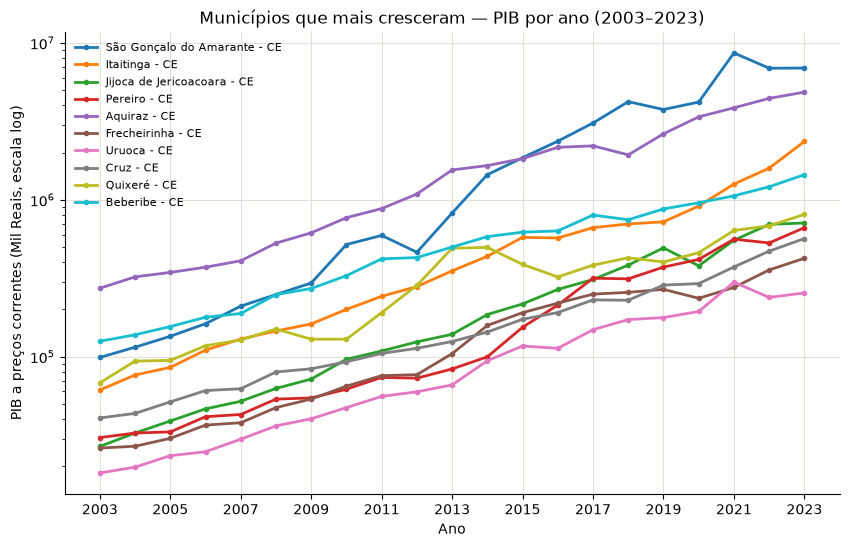

In [35]:
cores_top10 = plt.colormaps["tab10"].colors

fig, ax = plt.subplots(figsize=(10, 6))
for cor, municipio in zip(cores_top10, top10_mais_cresceram.index):
    serie = pib_municipios_pivot[municipio]
    ax.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais, escala log)")
ax.set_title("Municípios que mais cresceram — PIB por ano (2003–2023)")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

In [36]:
top10_menos_cresceram = crescimento_municipios.tail(10).sort_values()

print("Municípios que menos cresceram (2003 -> 2023)")
for posicao, (municipio, fator) in enumerate(top10_menos_cresceram.items(), start=1):
    print(f"{posicao:2d}. {municipio}: {fator:.2f}x")

Municípios que menos cresceram (2003 -> 2023)
 1. São João do Jaguaribe - CE: 3.81x
 2. Itapajé - CE: 3.82x
 3. Jaguaribara - CE: 3.91x
 4. Milagres - CE: 4.83x
 5. Orós - CE: 4.86x
 6. Aurora - CE: 5.00x
 7. Pacajus - CE: 5.05x
 8. Cascavel - CE: 5.08x
 9. Aratuba - CE: 5.10x
10. Paracuru - CE: 5.11x


Quais municípios menos cresceram em PIB entre 2003 e 2023?

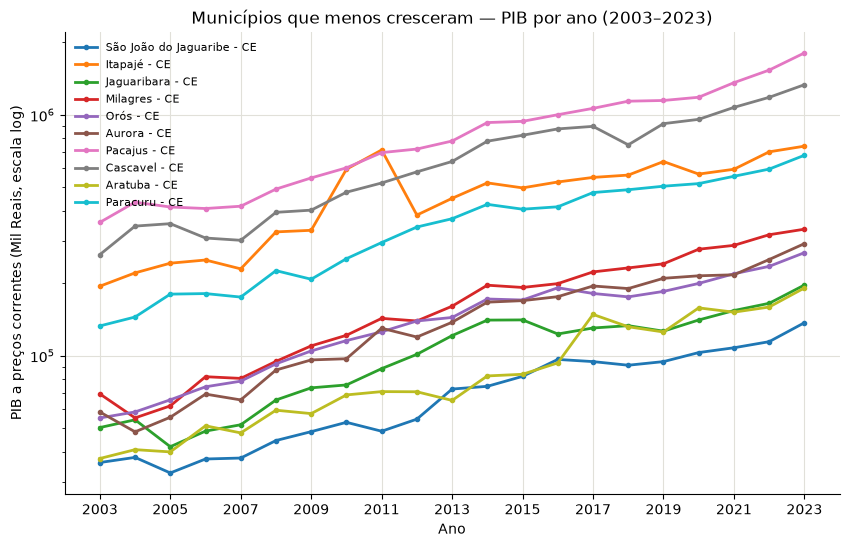

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
for cor, municipio in zip(cores_top10, top10_menos_cresceram.index):
    serie = pib_municipios_pivot[municipio]
    ax.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais, escala log)")
ax.set_title("Municípios que menos cresceram — PIB por ano (2003–2023)")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

Qual foi o de Baturité nesse período?

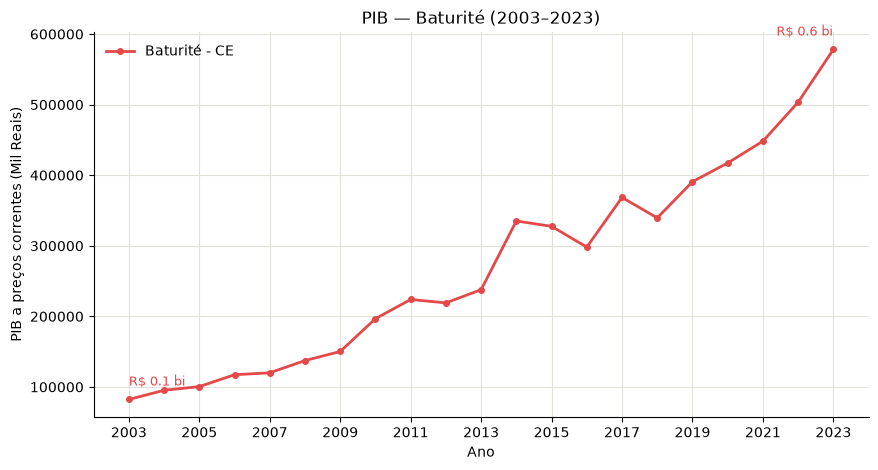

In [38]:
serie_baturite = pib_municipios_pivot["Baturité - CE"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(serie_baturite.index, serie_baturite.values, color="#e34948", linewidth=2, marker="o", markersize=4, label="Baturité - CE")

primeiro_ano, ultimo_ano = serie_baturite.index.min(), serie_baturite.index.max()
ax.annotate(
    formata_reais(serie_baturite.loc[primeiro_ano]),
    (primeiro_ano, serie_baturite.loc[primeiro_ano]),
    textcoords="offset points", xytext=(0, 10), ha="left", fontsize=9, color="#e34948",
)
ax.annotate(
    formata_reais(serie_baturite.loc[ultimo_ano]),
    (ultimo_ano, serie_baturite.loc[ultimo_ano]),
    textcoords="offset points", xytext=(0, 10), ha="right", fontsize=9, color="#e34948",
)

ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais)")
ax.set_title("PIB — Baturité (2003–2023)")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

### Outliers no PIB dos municípios

Existem outliers no PIB dos municípios? Como é a distribuição por ano?

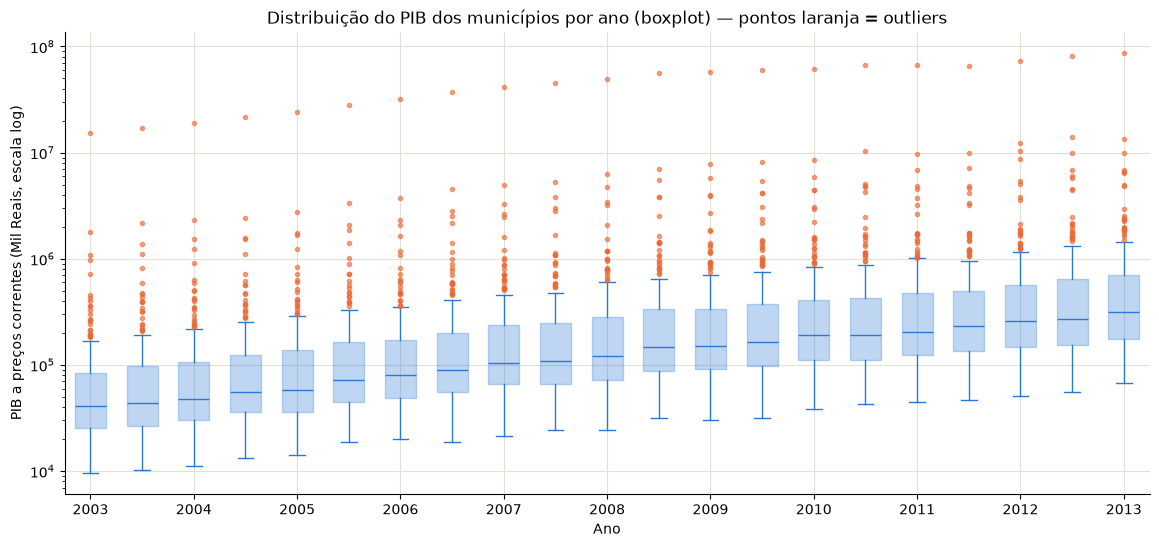

In [39]:
dados_boxplot = [pib_municipios_pivot.loc[ano].dropna().values for ano in pib_municipios_pivot.index]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(
    dados_boxplot,
    positions=pib_municipios_pivot.index,
    widths=0.6,
    patch_artist=True,
    flierprops={"markerfacecolor": "#eb6834", "markeredgecolor": "#eb6834", "markersize": 3, "alpha": 0.6},
    boxprops={"facecolor": "#2a78d6", "alpha": 0.3, "edgecolor": "#2a78d6"},
    medianprops={"color": "#2a78d6"},
    whiskerprops={"color": "#2a78d6"},
    capprops={"color": "#2a78d6"},
)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais, escala log)")
ax.set_title("Distribuição do PIB dos municípios por ano (boxplot) — pontos laranja = outliers")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

In [40]:
for ano in pib_municipios_pivot.index:
    valores_ano = pib_municipios_pivot.loc[ano].dropna()
    q1_ano = valores_ano.quantile(0.25)
    q3_ano = valores_ano.quantile(0.75)
    limite_ano = q3_ano + 1.5 * (q3_ano - q1_ano)
    outliers_ano = valores_ano[valores_ano > limite_ano].sort_values(ascending=False)

    nomes = ", ".join(f"{municipio} ({formata_reais(valor)})" for municipio, valor in outliers_ano.items())
    print(f"{ano}: {nomes}")

2003: Fortaleza - CE (R$ 15.2 bi), Maracanaú - CE (R$ 1.8 bi), Sobral - CE (R$ 1.1 bi), Caucaia - CE (R$ 1.0 bi), Juazeiro do Norte - CE (R$ 0.7 bi), Eusébio - CE (R$ 0.5 bi), Crato - CE (R$ 0.4 bi), Horizonte - CE (R$ 0.4 bi), Pacajus - CE (R$ 0.4 bi), Iguatu - CE (R$ 0.4 bi), Itapipoca - CE (R$ 0.3 bi), Maranguape - CE (R$ 0.3 bi), Aquiraz - CE (R$ 0.3 bi), Cascavel - CE (R$ 0.3 bi), Aracati - CE (R$ 0.3 bi), Russas - CE (R$ 0.2 bi), Limoeiro do Norte - CE (R$ 0.2 bi), Quixadá - CE (R$ 0.2 bi), Tianguá - CE (R$ 0.2 bi), Itapajé - CE (R$ 0.2 bi), Crateús - CE (R$ 0.2 bi), Pacatuba - CE (R$ 0.2 bi), Quixeramobim - CE (R$ 0.2 bi), Morada Nova - CE (R$ 0.2 bi)
2004: Fortaleza - CE (R$ 17.1 bi), Maracanaú - CE (R$ 2.2 bi), Sobral - CE (R$ 1.4 bi), Caucaia - CE (R$ 1.1 bi), Juazeiro do Norte - CE (R$ 0.8 bi), Eusébio - CE (R$ 0.6 bi), Horizonte - CE (R$ 0.5 bi), Crato - CE (R$ 0.5 bi), Pacajus - CE (R$ 0.4 bi), Iguatu - CE (R$ 0.4 bi), Itapipoca - CE (R$ 0.4 bi), Maranguape - CE (R$ 0.4 bi

In [41]:
print("Média do PIB por ano — com e sem outliers")
for ano in pib_municipios_pivot.index:
    valores_ano = pib_municipios_pivot.loc[ano].dropna()
    q1_ano = valores_ano.quantile(0.25)
    q3_ano = valores_ano.quantile(0.75)
    limite_ano = q3_ano + 1.5 * (q3_ano - q1_ano)

    sem_outliers = valores_ano[valores_ano <= limite_ano]

    media_com = valores_ano.mean()
    media_sem = sem_outliers.mean()

    print(f"{ano}: com outliers = {formata_reais(media_com)} | sem outliers = {formata_reais(media_sem)}")

Média do PIB por ano — com e sem outliers
2003: com outliers = R$ 0.2 bi | sem outliers = R$ 0.0 bi
2004: com outliers = R$ 0.2 bi | sem outliers = R$ 0.1 bi
2005: com outliers = R$ 0.2 bi | sem outliers = R$ 0.1 bi
2006: com outliers = R$ 0.3 bi | sem outliers = R$ 0.1 bi
2007: com outliers = R$ 0.3 bi | sem outliers = R$ 0.1 bi
2008: com outliers = R$ 0.3 bi | sem outliers = R$ 0.1 bi
2009: com outliers = R$ 0.4 bi | sem outliers = R$ 0.1 bi
2010: com outliers = R$ 0.4 bi | sem outliers = R$ 0.1 bi
2011: com outliers = R$ 0.5 bi | sem outliers = R$ 0.1 bi
2012: com outliers = R$ 0.5 bi | sem outliers = R$ 0.1 bi
2013: com outliers = R$ 0.6 bi | sem outliers = R$ 0.2 bi
2014: com outliers = R$ 0.7 bi | sem outliers = R$ 0.2 bi
2015: com outliers = R$ 0.7 bi | sem outliers = R$ 0.2 bi
2016: com outliers = R$ 0.8 bi | sem outliers = R$ 0.2 bi
2017: com outliers = R$ 0.8 bi | sem outliers = R$ 0.2 bi
2018: com outliers = R$ 0.8 bi | sem outliers = R$ 0.2 bi
2019: com outliers = R$ 0.9 bi

Como fica a distribuição do PIB de todos os municípios, ano a ano, em pontos?

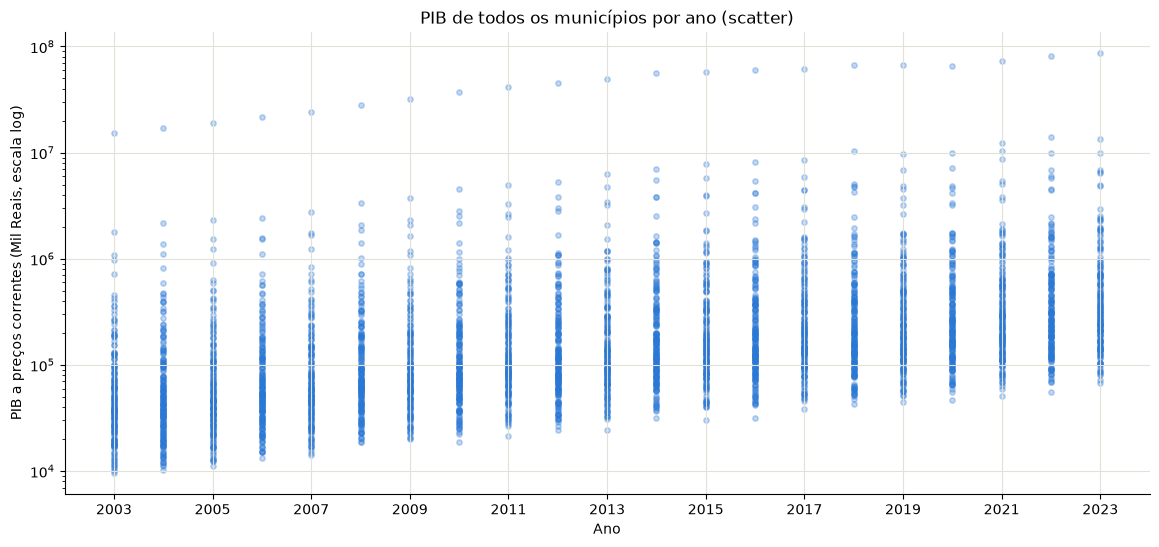

In [42]:
fig, ax = plt.subplots(figsize=(14, 6))
for ano in pib_municipios_pivot.index:
    valores_ano = pib_municipios_pivot.loc[ano].dropna()
    ax.scatter([ano] * len(valores_ano), valores_ano.values, color="#2a78d6", alpha=0.3, s=15)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais, escala log)")
ax.set_title("PIB de todos os municípios por ano (scatter)")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

In [43]:
valores_2023 = pib_municipios_pivot.loc[2023].dropna()

q1 = valores_2023.quantile(0.25)
q3 = valores_2023.quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr

outliers_2023 = valores_2023[valores_2023 > limite_superior].sort_values(ascending=False)

print(f"Limite superior (Q3 + 1.5*IQR): {formata_reais(limite_superior)}")
print(f"Outliers em 2023: {len(outliers_2023)}\n")
for municipio, valor in outliers_2023.items():
    print(f"{municipio}: {formata_reais(valor)}")

Limite superior (Q3 + 1.5*IQR): R$ 1.5 bi
Outliers em 2023: 23

Fortaleza - CE: R$ 86.9 bi
Maracanaú - CE: R$ 13.5 bi
Caucaia - CE: R$ 9.9 bi
São Gonçalo do Amarante - CE: R$ 6.9 bi
Sobral - CE: R$ 6.6 bi
Juazeiro do Norte - CE: R$ 6.5 bi
Eusébio - CE: R$ 4.9 bi
Aquiraz - CE: R$ 4.9 bi
Horizonte - CE: R$ 3.0 bi
Itapipoca - CE: R$ 2.6 bi
Crato - CE: R$ 2.4 bi
Itaitinga - CE: R$ 2.4 bi
Iguatu - CE: R$ 2.3 bi
Tianguá - CE: R$ 2.3 bi
Maranguape - CE: R$ 2.0 bi
Aracati - CE: R$ 2.0 bi
Quixeramobim - CE: R$ 1.9 bi
Morada Nova - CE: R$ 1.9 bi
Limoeiro do Norte - CE: R$ 1.9 bi
Pacajus - CE: R$ 1.8 bi
Pacatuba - CE: R$ 1.7 bi
Barbalha - CE: R$ 1.6 bi
Russas - CE: R$ 1.5 bi


In [44]:
df_municipios_reais.describe()

,ano_nome,valor,valor_is_inibido
count,11592.000000,1.085600e+04,11592.0
mean,2013.000000,3.839688e+05,0.0
std,6.055562,2.933235e+06,0.0
min,2003.000000,1.313000e+03,0.0
25%,2008.000000,2.559625e+04,0.0
50%,2013.000000,6.857750e+04,0.0
75%,2018.000000,1.796588e+05,0.0
max,2023.000000,8.693983e+07,0.0


Como foi o PIB de Fortaleza, Maracanaú, Eusébio, Pacajus, Cascavel, Baturité, Guaramiranga, Quixadá e Aiuaba?

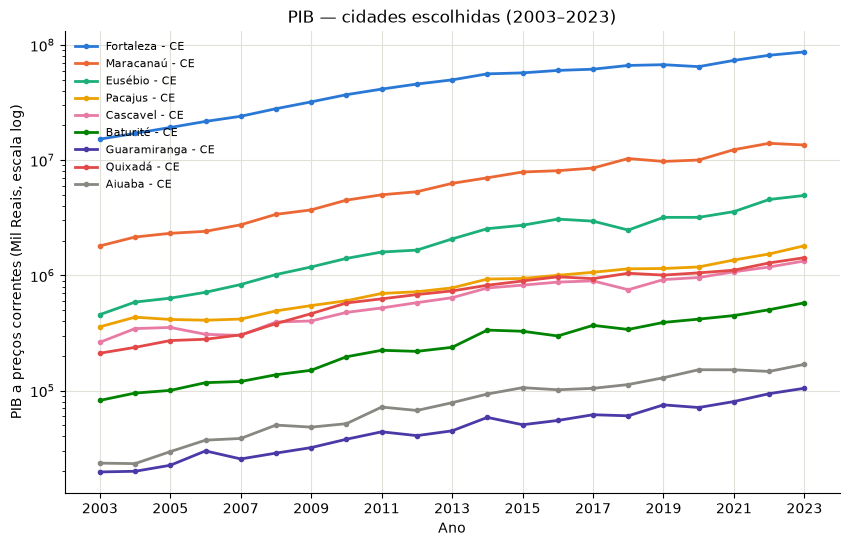

In [45]:
cidades_escolhidas = [
    "Fortaleza - CE",
    "Maracanaú - CE",
    "Eusébio - CE",
    "Pacajus - CE",
    "Cascavel - CE",
    "Baturité - CE",
    "Guaramiranga - CE",
    "Quixadá - CE",
    "Aiuaba - CE",
]
cidades_disponiveis = [c for c in cidades_escolhidas if c in pib_municipios_pivot.columns]

cores_escolhidas = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948", "#898781"]
cor_por_cidade = dict(zip(cidades_disponiveis, cores_escolhidas))

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_disponiveis:
    serie = pib_municipios_pivot[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais, escala log)")
ax.set_title("PIB — cidades escolhidas (2003–2023)")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

In [46]:
crescimento_escolhidas = (pib_municipios_pivot.loc[2023, cidades_disponiveis] / pib_municipios_pivot.loc[2003, cidades_disponiveis]).sort_values(ascending=False)

print("Crescimento do PIB (2003 -> 2023) — cidades escolhidas")
for municipio, fator in crescimento_escolhidas.items():
    print(f"{municipio}: {fator:.2f}x")

Crescimento do PIB (2003 -> 2023) — cidades escolhidas
Eusébio - CE: 10.82x
Maracanaú - CE: 7.51x
Aiuaba - CE: 7.20x
Baturité - CE: 7.03x
Quixadá - CE: 6.75x
Fortaleza - CE: 5.71x
Guaramiranga - CE: 5.32x
Cascavel - CE: 5.08x
Pacajus - CE: 5.05x


Quanto cada município representa do PIB do Ceará em 2023?

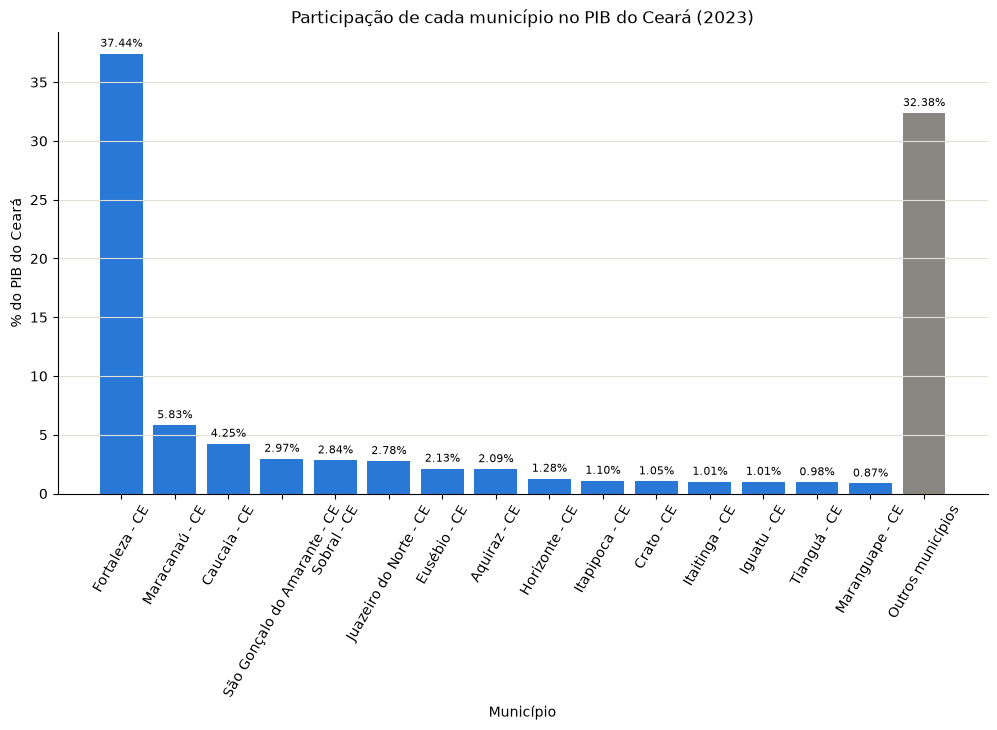

In [47]:
participacao_municipios_2023 = (pib_municipios_pivot.loc[2023] / pib_pivot.loc[2023, "Ceará"]) * 100
participacao_municipios_2023 = participacao_municipios_2023.sort_values(ascending=False)

top15_participacao = participacao_municipios_2023.head(15)
outros_participacao = participacao_municipios_2023.iloc[15:].sum()

categorias = list(top15_participacao.index) + ["Outros municípios"]
valores_participacao = list(top15_participacao.values) + [outros_participacao]
cores_participacao = ["#2a78d6"] * 15 + ["#898781"]

fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(categorias, valores_participacao, color=cores_participacao)
ax.bar_label(barras, fmt="%.2f%%", fontsize=8, padding=3)

ax.set_xlabel("Município")
ax.set_ylabel("% do PIB do Ceará")
ax.set_title("Participação de cada município no PIB do Ceará (2023)")
ax.tick_params(axis="x", rotation=60)
ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

Quanto cada município representava do PIB do Ceará em 2003?

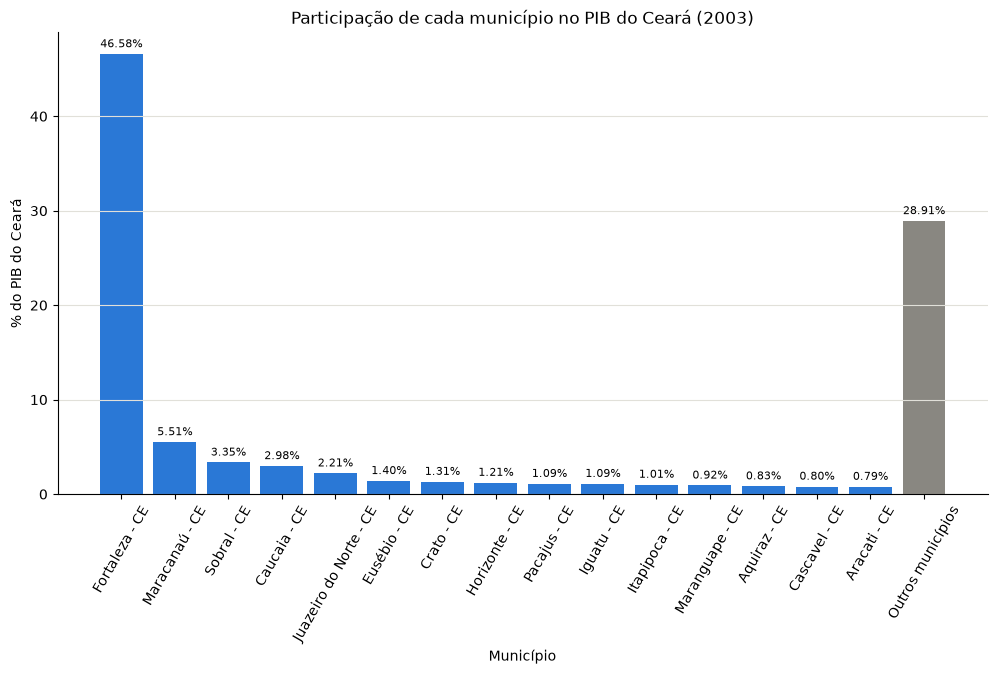

In [48]:
participacao_municipios_2003 = (pib_municipios_pivot.loc[2003] / pib_pivot.loc[2003, "Ceará"]) * 100
participacao_municipios_2003 = participacao_municipios_2003.sort_values(ascending=False)

top15_participacao_2003 = participacao_municipios_2003.head(15)
outros_participacao_2003 = participacao_municipios_2003.iloc[15:].sum()

categorias_2003 = list(top15_participacao_2003.index) + ["Outros municípios"]
valores_participacao_2003 = list(top15_participacao_2003.values) + [outros_participacao_2003]
cores_participacao_2003 = ["#2a78d6"] * 15 + ["#898781"]

fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(categorias_2003, valores_participacao_2003, color=cores_participacao_2003)
ax.bar_label(barras, fmt="%.2f%%", fontsize=8, padding=3)

ax.set_xlabel("Município")
ax.set_ylabel("% do PIB do Ceará")
ax.set_title("Participação de cada município no PIB do Ceará (2003)")
ax.tick_params(axis="x", rotation=60)
ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

In [49]:
print("Participação de cada município no PIB do Ceará — 2023")
for municipio, pct in participacao_municipios_2023.items():
    print(f"{municipio}: {pct:.2f}%")

Participação de cada município no PIB do Ceará — 2023
Fortaleza - CE: 37.44%
Maracanaú - CE: 5.83%
Caucaia - CE: 4.25%
São Gonçalo do Amarante - CE: 2.97%
Sobral - CE: 2.84%
Juazeiro do Norte - CE: 2.78%
Eusébio - CE: 2.13%
Aquiraz - CE: 2.09%
Horizonte - CE: 1.28%
Itapipoca - CE: 1.10%
Crato - CE: 1.05%
Itaitinga - CE: 1.01%
Iguatu - CE: 1.01%
Tianguá - CE: 0.98%
Maranguape - CE: 0.87%
Aracati - CE: 0.85%
Quixeramobim - CE: 0.83%
Morada Nova - CE: 0.81%
Limoeiro do Norte - CE: 0.80%
Pacajus - CE: 0.78%
Pacatuba - CE: 0.74%
Barbalha - CE: 0.71%
Russas - CE: 0.65%
Beberibe - CE: 0.62%
Quixadá - CE: 0.61%
Cascavel - CE: 0.57%
Brejo Santo - CE: 0.54%
Crateús - CE: 0.54%
Acaraú - CE: 0.54%
Canindé - CE: 0.51%
Trairi - CE: 0.45%
Camocim - CE: 0.42%
Tauá - CE: 0.40%
Icó - CE: 0.40%
São Benedito - CE: 0.38%
Guaraciaba do Norte - CE: 0.38%
Santa Quitéria - CE: 0.37%
Ubajara - CE: 0.36%
Amontada - CE: 0.35%
Quixeré - CE: 0.35%
Itapajé - CE: 0.32%
Jaguaribe - CE: 0.32%
Viçosa do Ceará - CE: 0.31

Como o PIB do Ceará se reparte entre os 184 municípios, visualmente?

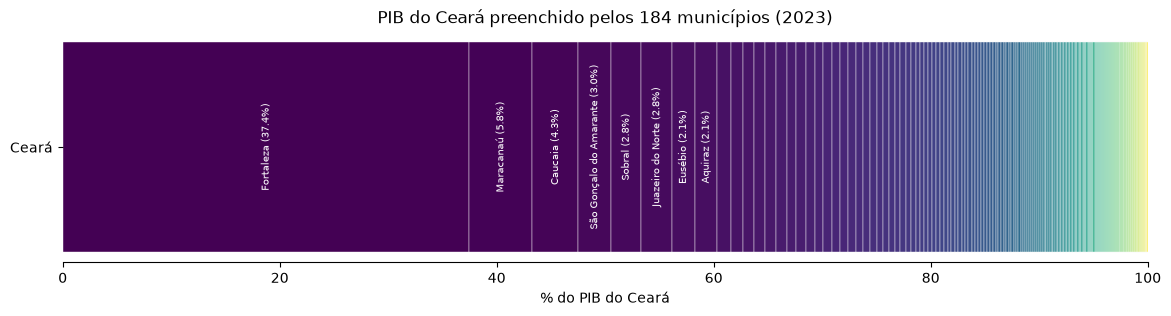

In [50]:
cmap_municipios = plt.colormaps["viridis"]
n = len(participacao_municipios_2023)

fig, ax = plt.subplots(figsize=(14, 3))
esquerda = 0
for posicao, (municipio, pct) in enumerate(participacao_municipios_2023.items()):
    cor = cmap_municipios(posicao / n)
    ax.barh("Ceará", pct, left=esquerda, color=cor, edgecolor="#fcfcfb", linewidth=0.3)
    if pct > 1.5:
        ax.text(esquerda + pct / 2, 0, f"{municipio.replace(' - CE', '')} ({pct:.1f}%)", ha="center", va="center", fontsize=7, color="white", rotation=90)
    esquerda += pct

ax.set_xlabel("% do PIB do Ceará")
ax.set_title("PIB do Ceará preenchido pelos 184 municípios (2023)")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

Como se compara o PIB de Fortaleza, Maracanaú, Caucaia e São Gonçalo do Amarante?

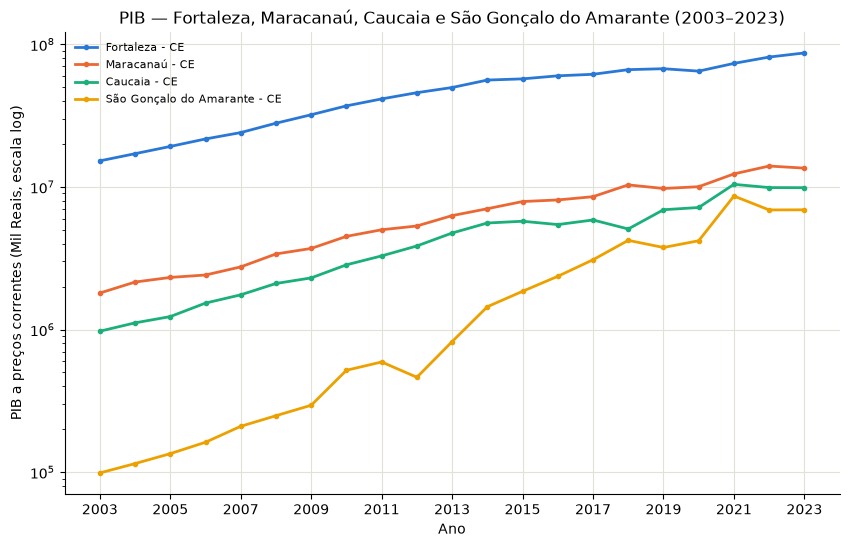

In [51]:
cidades_investigar = ["Fortaleza - CE", "Maracanaú - CE", "Caucaia - CE", "São Gonçalo do Amarante - CE"]
cores_investigar = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
cor_por_cidade_investigar = dict(zip(cidades_investigar, cores_investigar))

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = pib_municipios_pivot[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("PIB a preços correntes (Mil Reais, escala log)")
ax.set_title("PIB — Fortaleza, Maracanaú, Caucaia e São Gonçalo do Amarante (2003–2023)")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

In [52]:
crescimento_todos = pd.concat([
    pd.Series(crescimento),
    crescimento_municipios,
]).sort_values(ascending=False)

territorio_maior_crescimento = crescimento_todos.index[0]
fator_maior_crescimento = crescimento_todos.iloc[0]

print(f"Maior crescimento de PIB (2003 -> 2023) entre Brasil, Ceará e os {len(crescimento_municipios)} municípios:")
print(f"{territorio_maior_crescimento}: {fator_maior_crescimento:.2f}x")

Maior crescimento de PIB (2003 -> 2023) entre Brasil, Ceará e os 184 municípios:
São Gonçalo do Amarante - CE: 69.97x


In [53]:
print("CAGR — taxa de crescimento anual composta (2003 -> 2023)")
n_anos = 2023 - 2003
for municipio in cidades_investigar:
    valor_2003 = pib_municipios_pivot.loc[2003, municipio]
    valor_2023 = pib_municipios_pivot.loc[2023, municipio]
    cagr = (valor_2023 / valor_2003) ** (1 / n_anos) - 1
    print(f"{municipio}: {cagr * 100:.2f}% ao ano")

CAGR — taxa de crescimento anual composta (2003 -> 2023)
Fortaleza - CE: 9.10% ao ano
Maracanaú - CE: 10.61% ao ano
Caucaia - CE: 12.28% ao ano
São Gonçalo do Amarante - CE: 23.66% ao ano


In [54]:
print("Ano do maior salto (maior crescimento % de um ano pro outro)")
for municipio in cidades_investigar:
    serie = pib_municipios_pivot[municipio]
    variacao_anual = serie.pct_change().dropna() * 100
    ano_maior_salto = variacao_anual.idxmax()
    salto = variacao_anual.loc[ano_maior_salto]
    valor_antes = serie.loc[ano_maior_salto - 1]
    valor_depois = serie.loc[ano_maior_salto]
    print(f"{municipio}: {ano_maior_salto} ({salto:.1f}% em relação ao ano anterior) — de {formata_reais(valor_antes)} ({ano_maior_salto - 1}) para {formata_reais(valor_depois)} ({ano_maior_salto})")

Ano do maior salto (maior crescimento % de um ano pro outro)
Fortaleza - CE: 2008 (16.3% em relação ao ano anterior) — de R$ 24.0 bi (2007) para R$ 28.0 bi (2008)
Maracanaú - CE: 2008 (23.2% em relação ao ano anterior) — de R$ 2.7 bi (2007) para R$ 3.4 bi (2008)
Caucaia - CE: 2021 (45.3% em relação ao ano anterior) — de R$ 7.2 bi (2020) para R$ 10.4 bi (2021)
São Gonçalo do Amarante - CE: 2021 (105.7% em relação ao ano anterior) — de R$ 4.2 bi (2020) para R$ 8.6 bi (2021)


Qual a variação percentual anual do PIB dessas 4 cidades?

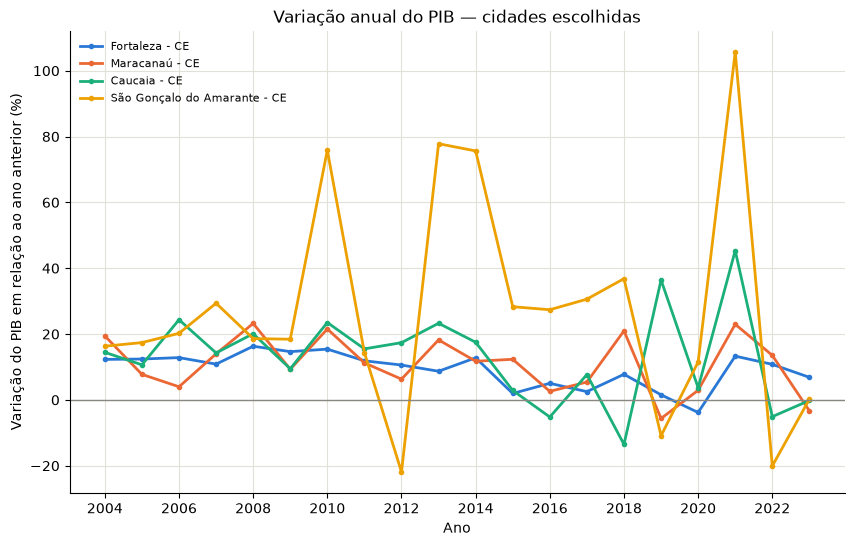

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = pib_municipios_pivot[municipio]
    variacao_anual = serie.pct_change().dropna() * 100
    ax.plot(variacao_anual.index, variacao_anual.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.axhline(0, color="#898781", linewidth=1)
ax.set_xlabel("Ano")
ax.set_ylabel("Variação do PIB em relação ao ano anterior (%)")
ax.set_title("Variação anual do PIB — cidades escolhidas")
ax.set_xticks(range(2004, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

In [56]:
correlacao = pib_municipios_pivot[cidades_investigar].pct_change().dropna().corr()
print("Correlação entre a variação anual do PIB das cidades escolhidas")
correlacao

Correlação entre a variação anual do PIB das cidades escolhidas


territorio_nome,Fortaleza - CE,Maracanaú - CE,Caucaia - CE,São Gonçalo do Amarante - CE
territorio_nome,,,,
Fortaleza - CE,1.000000,0.575302,0.318165,0.268099
Maracanaú - CE,0.575302,1.000000,0.142129,0.572325
Caucaia - CE,0.318165,0.142129,1.000000,0.402601
São Gonçalo do Amarante - CE,0.268099,0.572325,0.402601,1.000000


Como mudou a posição no ranking de PIB dessas 4 cidades ao longo do tempo?

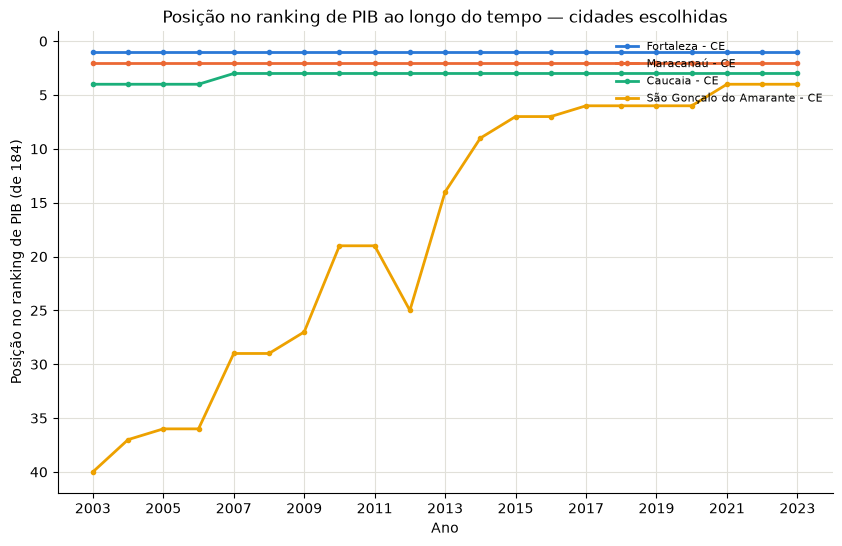

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    posicoes = ranking_por_ano[municipio]
    ax.plot(posicoes.index, posicoes.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.invert_yaxis()
ax.set_xlabel("Ano")
ax.set_ylabel(f"Posição no ranking de PIB (de {pib_municipios_pivot.shape[1]})")
ax.set_title("Posição no ranking de PIB ao longo do tempo — cidades escolhidas")
ax.set_xticks(range(2003, 2024, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper right")

plt.show()

## VAB Total — Brasil x Ceará

Como evoluiu o VAB total do Brasil e do Ceará?

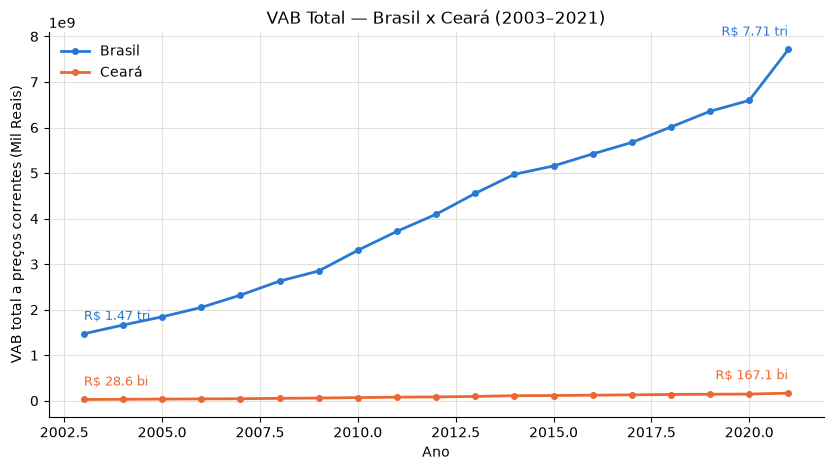

In [58]:
vab_bc = df_pib_sem_codigo[
    (df_pib_sem_codigo["territorio_nome"].isin(["Brasil", "Ceará"]))
    & (df_pib_sem_codigo["variavel_nome"] == "Valor adicionado bruto a preços correntes total")
].copy()
vab_bc["ano_nome"] = vab_bc["ano_nome"].astype(int)
vab_pivot = vab_bc.pivot(index="ano_nome", columns="territorio_nome", values="valor").dropna()

fig, ax = plt.subplots(figsize=(10, 5))
for territorio, cor in cores.items():
    serie = vab_pivot[territorio]
    ax.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)
    ax.annotate(formata_reais(serie.iloc[0]), (serie.index[0], serie.iloc[0]), textcoords="offset points", xytext=(0, 10), ha="left", fontsize=9, color=cor)
    ax.annotate(formata_reais(serie.iloc[-1]), (serie.index[-1], serie.iloc[-1]), textcoords="offset points", xytext=(0, 10), ha="right", fontsize=9, color=cor)

ax.set_xlabel("Ano")
ax.set_ylabel("VAB total a preços correntes (Mil Reais)")
ax.set_title(f"VAB Total — Brasil x Ceará ({vab_pivot.index.min()}–{vab_pivot.index.max()})")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

In [59]:
ano_final_vab = vab_pivot.index.max()
crescimento_vab = vab_pivot.loc[ano_final_vab] / vab_pivot.loc[2003]

print(f"Crescimento do VAB total (2003 -> {ano_final_vab})")
for territorio, fator in crescimento_vab.items():
    print(f"{territorio}: {fator:.2f}x")
print(f"Brasil cresceu {crescimento_vab['Brasil'] / crescimento_vab['Ceará']:.2f}x em relação ao Ceará")

Crescimento do VAB total (2003 -> 2021)
Brasil: 5.25x
Ceará: 5.84x
Brasil cresceu 0.90x em relação ao Ceará


## VAB Total — Municípios

Quais os 10 municípios com maior VAB total?

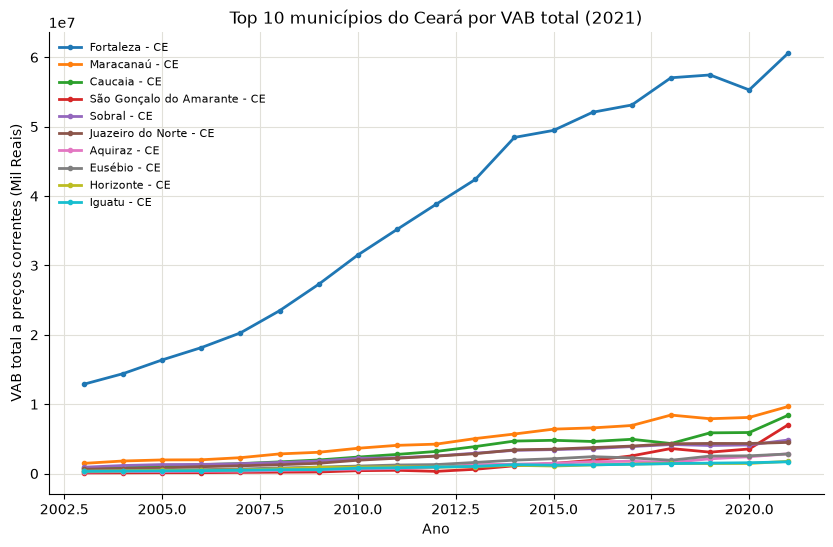

In [60]:
vab_municipios = df_municipios_reais[
    df_municipios_reais["variavel_nome"] == "Valor adicionado bruto a preços correntes total"
].copy()
vab_municipios_pivot = vab_municipios.pivot(index="ano_nome", columns="territorio_nome", values="valor").dropna(how="all")

ano_vab_mun = vab_municipios_pivot.index.max()
top10_vab_municipios = vab_municipios_pivot.loc[ano_vab_mun].sort_values(ascending=False).head(10).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
for cor, municipio in zip(cores_top10, top10_vab_municipios):
    serie = vab_municipios_pivot[municipio]
    ax.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_xlabel("Ano")
ax.set_ylabel("VAB total a preços correntes (Mil Reais)")
ax.set_title(f"Top 10 municípios do Ceará por VAB total ({ano_vab_mun})")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

Quanto cada município representa do VAB total do Ceará?

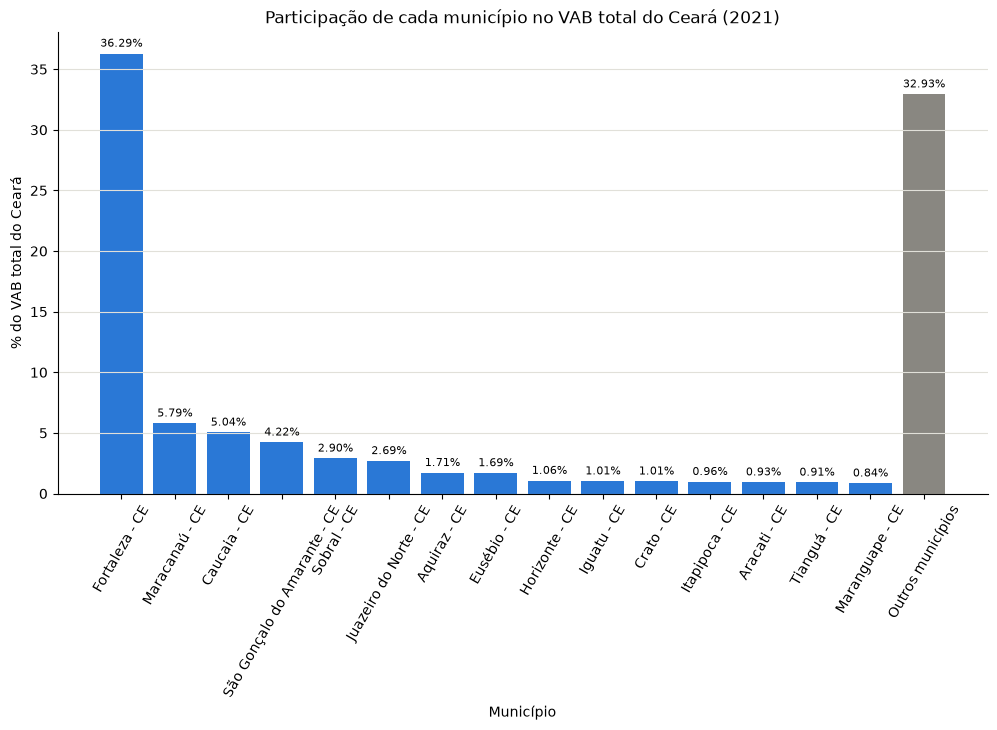

In [61]:
participacao_vab_municipios = (vab_municipios_pivot.loc[ano_vab_mun] / vab_pivot.loc[ano_vab_mun, "Ceará"]) * 100
participacao_vab_municipios = participacao_vab_municipios.sort_values(ascending=False)

top15_vab = participacao_vab_municipios.head(15)
outros_vab = participacao_vab_municipios.iloc[15:].sum()

categorias_vab = list(top15_vab.index) + ["Outros municípios"]
valores_vab = list(top15_vab.values) + [outros_vab]
cores_vab = ["#2a78d6"] * 15 + ["#898781"]

fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(categorias_vab, valores_vab, color=cores_vab)
ax.bar_label(barras, fmt="%.2f%%", fontsize=8, padding=3)

ax.set_xlabel("Município")
ax.set_ylabel("% do VAB total do Ceará")
ax.set_title(f"Participação de cada município no VAB total do Ceará ({ano_vab_mun})")
ax.tick_params(axis="x", rotation=60)
ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

## VAB Agropecuário — Brasil x Ceará

Como evoluiu o VAB agropecuário do Brasil e do Ceará?

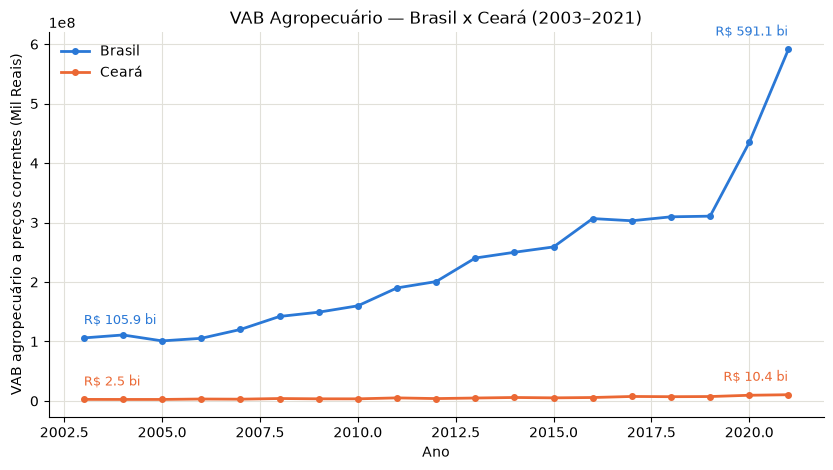

In [62]:
vab_agro_bc = df_pib_sem_codigo[
    (df_pib_sem_codigo["territorio_nome"].isin(["Brasil", "Ceará"]))
    & (df_pib_sem_codigo["variavel_nome"] == "Valor adicionado bruto a preços correntes da agropecuária")
].copy()
vab_agro_bc["ano_nome"] = vab_agro_bc["ano_nome"].astype(int)
vab_agro_pivot = vab_agro_bc.pivot(index="ano_nome", columns="territorio_nome", values="valor").dropna()

fig, ax = plt.subplots(figsize=(10, 5))
for territorio, cor in cores.items():
    serie = vab_agro_pivot[territorio]
    ax.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)
    ax.annotate(formata_reais(serie.iloc[0]), (serie.index[0], serie.iloc[0]), textcoords="offset points", xytext=(0, 10), ha="left", fontsize=9, color=cor)
    ax.annotate(formata_reais(serie.iloc[-1]), (serie.index[-1], serie.iloc[-1]), textcoords="offset points", xytext=(0, 10), ha="right", fontsize=9, color=cor)

ax.set_xlabel("Ano")
ax.set_ylabel("VAB agropecuário a preços correntes (Mil Reais)")
ax.set_title(f"VAB Agropecuário — Brasil x Ceará ({vab_agro_pivot.index.min()}–{vab_agro_pivot.index.max()})")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

In [63]:
ano_final_vab_agro = vab_agro_pivot.index.max()
crescimento_vab_agro = vab_agro_pivot.loc[ano_final_vab_agro] / vab_agro_pivot.loc[2003]

print(f"Crescimento do VAB agropecuário (2003 -> {ano_final_vab_agro})")
for territorio, fator in crescimento_vab_agro.items():
    print(f"{territorio}: {fator:.2f}x")
print(f"Brasil cresceu {crescimento_vab_agro['Brasil'] / crescimento_vab_agro['Ceará']:.2f}x em relação ao Ceará")

Crescimento do VAB agropecuário (2003 -> 2021)
Brasil: 5.58x
Ceará: 4.09x
Brasil cresceu 1.37x em relação ao Ceará


## VAB Agropecuário — Municípios

Quais os 10 municípios com maior VAB agropecuário?

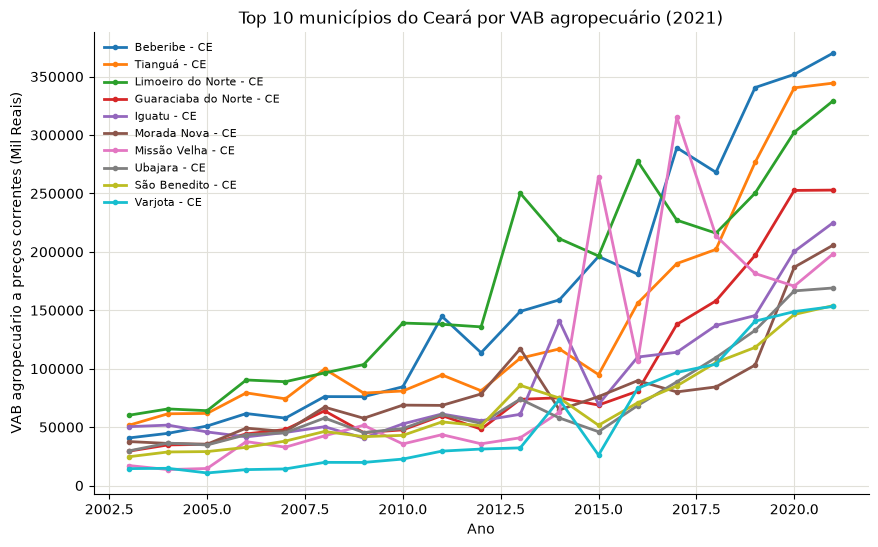

In [64]:
vab_agro_municipios = df_municipios_reais[
    df_municipios_reais["variavel_nome"] == "Valor adicionado bruto a preços correntes da agropecuária"
].copy()
vab_agro_municipios_pivot = vab_agro_municipios.pivot(index="ano_nome", columns="territorio_nome", values="valor").dropna(how="all")

ano_vab_agro_mun = vab_agro_municipios_pivot.index.max()
top10_vab_agro_municipios = vab_agro_municipios_pivot.loc[ano_vab_agro_mun].sort_values(ascending=False).head(10).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
for cor, municipio in zip(cores_top10, top10_vab_agro_municipios):
    serie = vab_agro_municipios_pivot[municipio]
    ax.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_xlabel("Ano")
ax.set_ylabel("VAB agropecuário a preços correntes (Mil Reais)")
ax.set_title(f"Top 10 municípios do Ceará por VAB agropecuário ({ano_vab_agro_mun})")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

Quanto cada município representa do VAB agropecuário do Ceará?

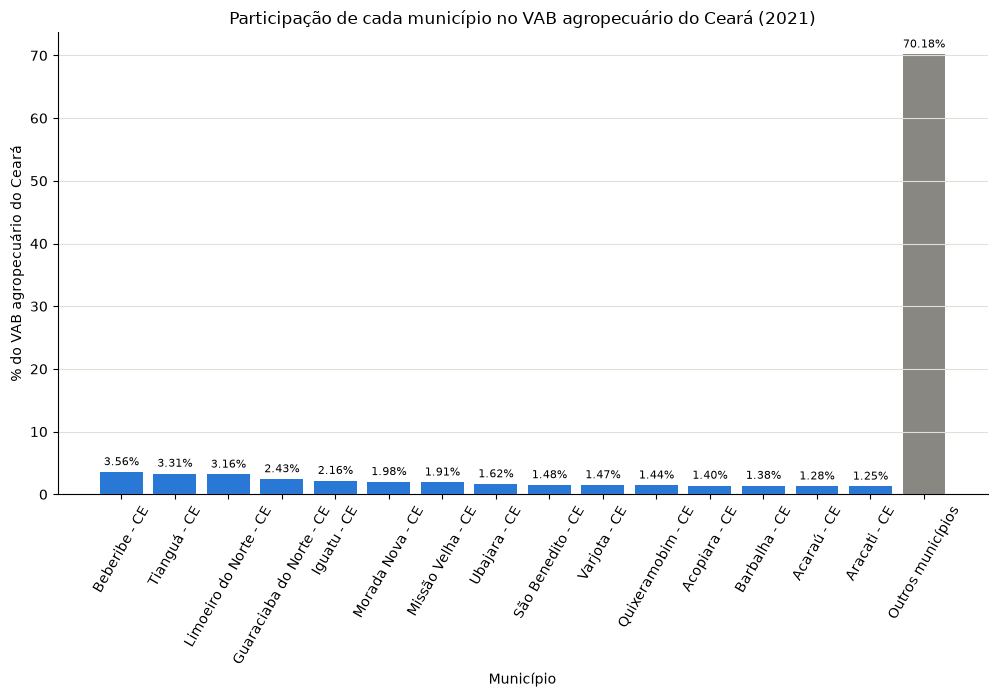

In [65]:
participacao_vab_agro_municipios = (vab_agro_municipios_pivot.loc[ano_vab_agro_mun] / vab_agro_pivot.loc[ano_vab_agro_mun, "Ceará"]) * 100
participacao_vab_agro_municipios = participacao_vab_agro_municipios.sort_values(ascending=False)

top15_vab_agro = participacao_vab_agro_municipios.head(15)
outros_vab_agro = participacao_vab_agro_municipios.iloc[15:].sum()

categorias_vab_agro = list(top15_vab_agro.index) + ["Outros municípios"]
valores_vab_agro = list(top15_vab_agro.values) + [outros_vab_agro]
cores_vab_agro = ["#2a78d6"] * 15 + ["#898781"]

fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(categorias_vab_agro, valores_vab_agro, color=cores_vab_agro)
ax.bar_label(barras, fmt="%.2f%%", fontsize=8, padding=3)

ax.set_xlabel("Município")
ax.set_ylabel("% do VAB agropecuário do Ceará")
ax.set_title(f"Participação de cada município no VAB agropecuário do Ceará ({ano_vab_agro_mun})")
ax.tick_params(axis="x", rotation=60)
ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

## Participação da Agropecuária no VAB — Brasil x Ceará

Como mudou o peso da agropecuária no VAB do Brasil e do Ceará?

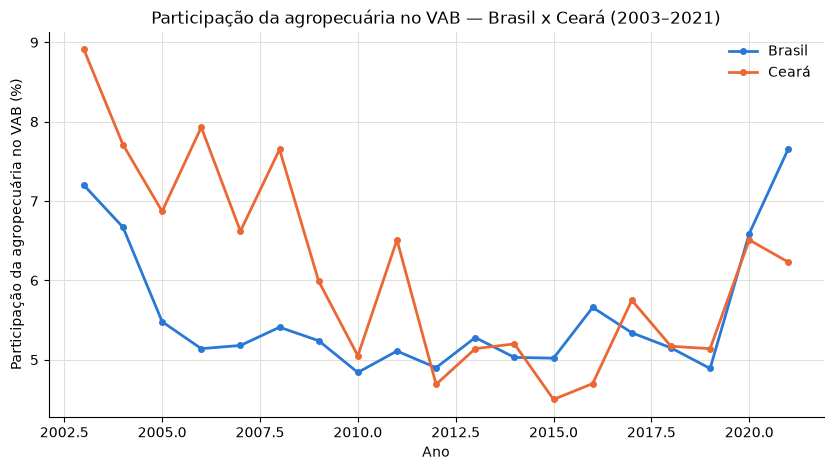

In [66]:
pct_agro_bc = df_pib_sem_codigo[
    (df_pib_sem_codigo["territorio_nome"].isin(["Brasil", "Ceará"]))
    & (df_pib_sem_codigo["variavel_nome"] == "Participação do valor adicionado bruto a preços correntes da agropecuária no valor adicionado bruto a preços correntes total")
].copy()
pct_agro_bc["ano_nome"] = pct_agro_bc["ano_nome"].astype(int)
pct_agro_pivot = pct_agro_bc.pivot(index="ano_nome", columns="territorio_nome", values="valor").dropna()

fig, ax = plt.subplots(figsize=(10, 5))
for territorio, cor in cores.items():
    serie = pct_agro_pivot[territorio]
    ax.plot(serie.index, serie.values, color=cor, linewidth=2, marker="o", markersize=4, label=territorio)

ax.set_xlabel("Ano")
ax.set_ylabel("Participação da agropecuária no VAB (%)")
ax.set_title(f"Participação da agropecuária no VAB — Brasil x Ceará ({pct_agro_pivot.index.min()}–{pct_agro_pivot.index.max()})")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

## Participação da Agropecuária no VAB — Municípios

In [67]:
pct_agro_municipios_pivot = df_municipios_pct.copy()
pct_agro_municipios_pivot["ano_nome"] = pct_agro_municipios_pivot["ano_nome"].astype(int)
pct_agro_municipios_pivot = pct_agro_municipios_pivot.pivot(index="ano_nome", columns="territorio_nome", values="valor").dropna(how="all")

ano_pct_mun = pct_agro_municipios_pivot.index.max()
ranking_pct_agro = pct_agro_municipios_pivot.loc[ano_pct_mun].sort_values(ascending=False)

top10_mais_dependentes = ranking_pct_agro.head(10)
top10_menos_dependentes = ranking_pct_agro.tail(10).sort_values()

print(f"Municípios mais dependentes da agropecuária ({ano_pct_mun})")
for municipio, pct in top10_mais_dependentes.items():
    print(f"{municipio}: {pct:.2f}%")

print(f"\nMunicípios menos dependentes da agropecuária ({ano_pct_mun})")
for municipio, pct in top10_menos_dependentes.items():
    print(f"{municipio}: {pct:.2f}%")

Municípios mais dependentes da agropecuária (2021)
São João do Jaguaribe - CE: 44.83%
Milhã - CE: 42.88%
Varjota - CE: 42.83%
Missão Velha - CE: 40.04%
Guaraciaba do Norte - CE: 40.00%
Independência - CE: 38.51%
Beberibe - CE: 36.49%
Quixelô - CE: 35.67%
Aratuba - CE: 35.14%
Croatá - CE: 34.69%

Municípios menos dependentes da agropecuária (2021)
Fortaleza - CE: 0.18%
Maracanaú - CE: 0.21%
São Gonçalo do Amarante - CE: 0.67%
Juazeiro do Norte - CE: 0.71%
Itaitinga - CE: 0.72%
Caucaia - CE: 0.77%
Eusébio - CE: 0.88%
Sobral - CE: 1.07%
Jijoca de Jericoacoara - CE: 1.80%
Pacatuba - CE: 2.60%


Quais municípios são mais dependentes da agropecuária?

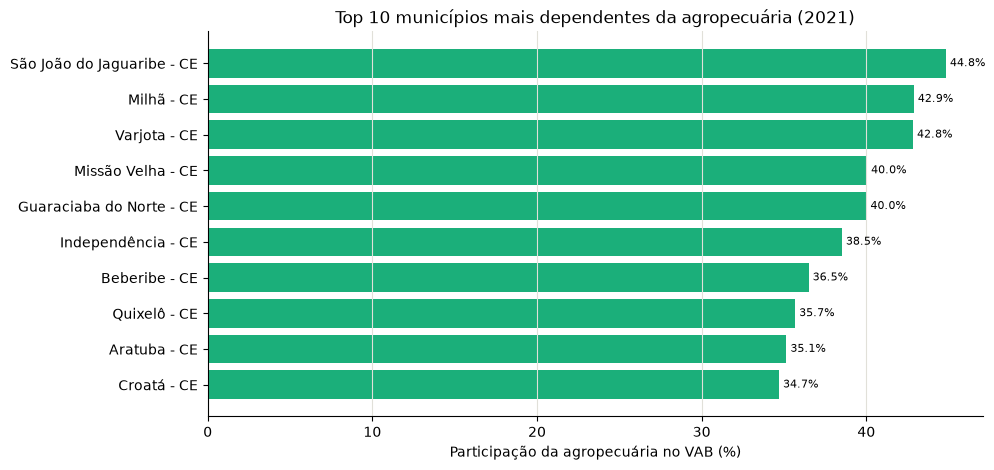

In [68]:
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(top10_mais_dependentes.index[::-1], top10_mais_dependentes.values[::-1], color="#1baf7a")
ax.bar_label(barras, fmt="%.1f%%", fontsize=8, padding=3)

ax.set_xlabel("Participação da agropecuária no VAB (%)")
ax.set_title(f"Top 10 municípios mais dependentes da agropecuária ({ano_pct_mun})")
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.show()